(06-35-machine-learning)=

# Machine learning in de cross-sectie

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 2018–2024: van Kozak, Nagel en Santosh en Gu, Kelly en Xiu tot de
"virtue of complexity" van Kelly, Malamud en Zhou.

**Wat we al weten.** De [factor zoo](#06-34-factor-zoo) liet honderden gepubliceerde
voorspellers achter, waarvan een deel datamining is, een deel na publicatie verdampt en
een deel elkaars variant is. Elk prijsmodel is een uitspraak over de stochastic discount
factor ([](#05-26-sdf-unificatie)), en een belegger kan met drie parameters een
portefeuille op karakteristieken bouwen zonder duizend gemiddelden te schatten
([](#05-31-portfolio-choice)). Uit [](#04-20-voorspelbaarheid) weten we hoe snel een
voorspeller die in-sample werkt out-of-sample onder het historische gemiddelde zakt.

**Welke vraag staat open.** Als we de hele zoo tegelijk aan een flexibele
voorspelmachine voeren en die streng out-of-sample beoordelen, blijft er dan
voorspelbaarheid over, en wat betekent die?
```

## Overzicht

Het werk dat dit tijdvak definieert is *Empirical Asset Pricing via Machine Learning*
van Shihao Gu, Bryan Kelly en Dacheng Xiu {cite}`GuKellyXiu2020`. Ze voerden 94
karakteristieken van bijna 30.000 Amerikaanse aandelen, gecombineerd met acht
macrovariabelen en 74 industriedummies, aan dertien voorspelmethoden en schatten ze
op 1957–1986 om ze op 1987–2016 te toetsen. Santa-Clara vat het resultaat samen:
"the machines forecast the cross-section of returns roughly twice as well as the linear
models", met de winst afkomstig van "nonlinearity and interaction rather than from any
new variable" {cite}`SantaClara2026`. Dat werk definieert het tijdvak omdat het de vraag
verlegde. Welke karakteristiek beprijsd is, werd minder belangrijk dan hoeveel
voorspelbaarheid een gedisciplineerde machine uit alle karakteristieken samen haalt.

Het is ook het punt waarop motief 3 zijn verste stap zet: van theorie-met-tests naar
voorspelling zonder theorie. Een neuraal netwerk dat 0,40% van de maandelijkse variantie
van losse aandelen voorspelt, is een *meting* van verwachte rendementen, geen verklaring
ervan. Daarom gaat deze lecture ook over drie tegenbewegingen die structuur terugbrengen:
Kelly, Pruitt en Su lezen karakteristieken als bèta's {cite}`KellyPruittSu2019`, Kozak,
Nagel en Santosh schatten de SDF zelf met een Bayesiaanse prior {cite}`KozakNagelSantosh2020`,
en Martin en Nagel laten zien dat in-sample voorspelbaarheid in een wereld met veel
karakteristieken zelfs bij volledig rationele beleggers te verwachten is
{cite}`MartinNagel2022`. Wie verder wil lezen: het boek van {cite:t}`Nagel2021` en het
overzicht van {cite:t}`KellyXiu2023`.

Na shrinkage en een regressieboom met de hand, de theorie en drie simulaties passen we de
methoden toe op de 212 long-short signaalportefeuilles van Open Source Asset Pricing
{cite}`ChenZimmermann2022`: voorspellen welk signaal volgende maand goed doet, en een
KNS-achtige SDF. Dat is uitdrukkelijk *geen* replicatie van Gu, Kelly en Xiu, want
aandeeldata zijn niet gratis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel dat een analist tweehonderd kenmerken van een aandeel kent. Het ware verwachte
rendement verschilt tussen aandelen misschien een paar procent per jaar; het gerealiseerde
rendement schommelt tien procent per maand. Wie tweehonderd regressiegewichten schat, past
vooral die schommelingen aan: elk gewicht pikt wat ruis op, en samen is dat meer dan het
signaal. Daarom voorspelt de gewone regressie met alle variabelen out-of-sample slechter
dan "nul".

Machine learning is in de eerste plaats een verzameling manieren om die ruis te
temmen. *Shrinkage* (krimp: gewichten systematisch naar nul trekken) ruilt een kleine,
bekende vertekening in voor een grote daling van de variantie. *Selectie* zet de meeste
gewichten precies op nul. *Dimensiereductie* middelt eerst veel verwante karakteristieken
tot een paar samenvattingen. Pas daarna komt flexibiliteit: een *regressieboom* (die de
aandelen herhaaldelijk in twee groepen splitst en per groep het gemiddelde neemt) of een
*neuraal netwerk* (een gelaagde, niet-lineaire functie) kan interacties vinden, zoals
"momentum werkt anders bij kleine aandelen", die een lineair model per constructie mist.
Die flexibiliteit is alleen bruikbaar met discipline: middelen, vroeg stoppen, en elke
keuze toetsen op data die bij het schatten niet gebruikt zijn.

Dan de vraag wat de gevonden voorspelbaarheid betekent. Santa-Clara noemt het de zesde
open vraag: "Whether machine-learning alphas are real. Gu, Kelly and Xiu's forecasts work
out of sample in the historical data. Whether they work after publication, at institutional
scale, after costs, and once the machines are trading against one another, is a different
question, and the history of every prior generation of anomalies suggests the answer will
disappoint" {cite}`SantaClara2026`. Martin en Nagel waarschuwen subtieler: als beleggers zelf moeten *leren* hoe
tweehonderd kenmerken met kasstromen samenhangen, zitten ze er elke periode een beetje naast.
Achteraf lijkt dat voorspelbaarheid, maar vooraf viel er niets aan te verdienen.

## Toy-voorbeeld: vijf aandelen, twee karakteristieken, één maand

Vijf aandelen hebben twee gestandaardiseerde karakteristieken $x_1$ en $x_2$ en een
cross-sectioneel gedemeand rendement $r$ (in procenten) in de maand erna:

| aandeel | $x_1$ | $x_2$ | $r$ |
|---|---|---|---|
| 1 | $-2$ | $1$ | $-3$ |
| 2 | $-1$ | $-2$ | $-2$ |
| 3 | $0$ | $0$ | $1$ |
| 4 | $1$ | $2$ | $0$ |
| 5 | $2$ | $-1$ | $4$ |

De kolommen zijn orthogonaal en hebben gemiddelde nul: $\mathbf{X}'\mathbf{X} = 10\,\mathbf{I}$.
Daardoor valt elke methode uiteen in twee losse problemen, één per karakteristiek. Met
$\mathbf{z} = \mathbf{X}'\mathbf{r}$ is $z_1 = 6 + 2 + 0 + 0 + 8 = 16$ en
$z_2 = -3 + 4 + 0 + 0 - 4 = -3$.

**OLS.** $\hat{\mathbf{b}} = \mathbf{z}/10 = (1{,}6;\,-0{,}3)$. Voorspellingen
$(-3{,}5;\,-1{,}0;\,0;\,1{,}0;\,3{,}5)$, residuen $(0{,}5;\,-1;\,1;\,-1;\,0{,}5)$, dus een
kwadratensom van 3,5 tegen een totale kwadratensom van 30: een in-sample $R^2$ van 88%.

**Ridge** met $\lambda = 10$ minimaliseert $\lVert \mathbf{r} - \mathbf{X}\mathbf{b}\rVert^2 + \lambda\lVert\mathbf{b}\rVert^2$.
De oplossing is $\mathbf{z}/(10+\lambda) = (0{,}8;\,-0{,}15)$: beide gewichten precies
gehalveerd. De voorspellingen worden $(-1{,}75;\,-0{,}5;\,0;\,0{,}5;\,1{,}75)$.

**LASSO** met $\lambda = 5$ minimaliseert $\tfrac12\lVert \mathbf{r} - \mathbf{X}\mathbf{b}\rVert^2 + \lambda\lVert\mathbf{b}\rVert_1$.
Bij orthogonale kolommen is de oplossing *soft-thresholding*:
$\hat b_j = \operatorname{sign}(z_j)\max(|z_j| - \lambda, 0)/10$. Dat geeft
$\hat b_1 = (16-5)/10 = 1{,}1$ en $\hat b_2 = 0$, want $|-3| < 5$. De tweede karakteristiek
verdwijnt; de voorspellingen worden $(-2{,}2;\,-1{,}1;\,0;\,1{,}1;\,2{,}2)$.

**Elastic net** met $\lambda_1 = 5$ en $\lambda_2 = 10$ (straf $\lambda_1\lVert\mathbf{b}\rVert_1 + \tfrac12\lambda_2\lVert\mathbf{b}\rVert^2$
bij dezelfde $\tfrac12$-kwadratensom) doet beide:
$\hat b_1 = (16-5)/(10+10) = 0{,}55$, $\hat b_2 = 0$.

Alle vier de oplossingen zijn gevallen van één formule, [](#eq-machine-learning-soft) in
[](#prop-machine-learning-gesloten) hieronder. Shrinkage trekt de voorspellingen dus naar het
cross-sectionele gemiddelde. Ridge doet dat
proportioneel en behoudt de rangorde, LASSO gooit de zwakke karakteristiek weg en krimpt de
sterke met een vast bedrag. Of dat beter is, kan dit voorbeeld niet zeggen: we kennen de ware
gewichten niet, en daarvoor is de simulatie.

**Een regressieboom met één split.** De boom probeert elke karakteristiek en elk
splitpunt, en kiest de split met de kleinste kwadratensom rond de twee groepsgemiddelden.
Op $x_1$ (aandelen in de volgorde 1–5, rendementen $-3, -2, 1, 0, 4$):

| split | links | rechts | kwadratensom |
|---|---|---|---|
| $x_1 \le -1{,}5$ | $\{-3\}$ | $\{-2, 1, 0, 4\}$, gem. 0,75 | 18,75 |
| $x_1 \le -0{,}5$ | $\{-3, -2\}$, gem. $-2{,}5$ | $\{1, 0, 4\}$, gem. $5/3$ | $0{,}5 + 78/9 = 9{,}17$ |
| $x_1 \le 0{,}5$ | $\{-3, -2, 1\}$, gem. $-4/3$ | $\{0, 4\}$, gem. 2 | $78/9 + 8 = 16{,}67$ |
| $x_1 \le 1{,}5$ | $\{-3,-2,1,0\}$, gem. $-1$ | $\{4\}$ | 10 |

Op $x_2$ (volgorde aandeel 2, 5, 3, 1, 4) zijn de vier kwadratensommen 25, 26,67, 22,5 en 30.
De beste split is $x_1 \le -0{,}5$: de boom voorspelt $-2{,}5$ voor aandelen 1 en 2 en
$1{,}67$ voor 3, 4 en 5. Hij gebruikt $x_2$ niet en legt een stapfunctie waar OLS een lijn
legt. Met diepere bomen kan hij ook interacties leggen: "splits eerst op $x_1$, en binnen
de hoge groep op $x_2$".

In [2]:
X_toy = np.array([[-2, 1], [-1, -2], [0, 0], [1, 2], [2, -1]], dtype=float)
r_toy = np.array([-3.0, -2.0, 1.0, 0.0, 4.0])
z_toy = X_toy.T @ r_toy                                   # (16, -3); X'X = 10 I

b_hand = {
    "OLS": z_toy / 10,
    "ridge (lambda=10)": z_toy / (10 + 10),
    "LASSO (lambda=5)": np.sign(z_toy) * np.maximum(np.abs(z_toy) - 5, 0) / 10,
    "elastic net (5, 10)": np.sign(z_toy) * np.maximum(np.abs(z_toy) - 5, 0) / (10 + 10),
}
# sklearn scales the squared loss by 1/(2n): alpha = lambda / n for the L1 part
b_sklearn = {
    "OLS": LinearRegression(fit_intercept=False).fit(X_toy, r_toy).coef_,
    "ridge (lambda=10)": Ridge(alpha=10, fit_intercept=False).fit(X_toy, r_toy).coef_,
    "LASSO (lambda=5)": Lasso(alpha=5 / 5, fit_intercept=False).fit(X_toy, r_toy).coef_,
    "elastic net (5, 10)": ElasticNet(alpha=3.0, l1_ratio=1 / 3,
                                      fit_intercept=False).fit(X_toy, r_toy).coef_,
}
tree = DecisionTreeRegressor(max_depth=1).fit(X_toy, r_toy)

toy = pd.DataFrame({name: X_toy @ b for name, b in b_hand.items()},
                   index=pd.Index(range(1, 6), name="aandeel"))
toy["boom (1 split)"] = tree.predict(X_toy)
toy.insert(0, "rendement", r_toy)

assert all(np.allclose(b_hand[k], b_sklearn[k], atol=1e-8) for k in b_hand)
assert tree.tree_.feature[0] == 0 and np.isclose(tree.tree_.threshold[0], -0.5)
print("coefficients (hand = sklearn):", {k: np.round(v, 3).tolist() for k, v in b_hand.items()})
print(f"boom: split op x{tree.tree_.feature[0] + 1} <= {tree.tree_.threshold[0]:.1f}")
toy.round(3)

coefficients (hand = sklearn): {'OLS': [1.6, -0.3], 'ridge (lambda=10)': [0.8, -0.15], 'LASSO (lambda=5)': [1.1, -0.0], 'elastic net (5, 10)': [0.55, -0.0]}
boom: split op x1 <= -0.5


,rendement,OLS,ridge (lambda=10),LASSO (lambda=5),"elastic net (5, 10)",boom (1 split)
aandeel,,,,,,
1,-3.0,-3.5,-1.75,-2.2,-1.10,-2.500
2,-2.0,-1.0,-0.50,-1.1,-0.55,-2.500
3,1.0,0.0,0.00,0.0,0.00,1.667
4,0.0,1.0,0.50,1.1,0.55,1.667
5,4.0,3.5,1.75,2.2,1.10,1.667


De code geeft dezelfde gewichten, voorspellingen en split als de handberekening. Let op de
schaalconventie van scikit-learn: `Lasso` deelt de kwadratensom door $2n$, dus
$\lambda = 5$ bij $n = 5$ wordt `alpha=1`.

## Theorie

### Voorspellen: bias tegenover variantie

*Waarom zou dit waar zijn?* Een voorspelfout heeft drie bronnen: ruis die niemand kan
voorspellen, een model dat de ware functie niet kan uitdrukken, en schattingsfout in de
parameters. De eerste staat vast. Een flexibeler model verkleint de tweede en vergroot de
derde. Bij rendementen, waar de ruis de variantie domineert, is de derde bron bijna altijd
de grootste.

Schrijf het excess rendement als $r_{i,t+1} = g^\star(\mathbf{z}_{i,t}) + \varepsilon_{i,t+1}$ met
$\E_t[\varepsilon_{i,t+1}] = 0$, waar $\mathbf{z}_{i,t}$ de $P$ voorspellers zijn en
$g^\star(\mathbf{z}_{i,t}) = \E_t[r_{i,t+1}]$. Gu, Kelly en Xiu gebruiken precies deze
opzet (hun vergelijkingen 1 en 2), met één functie $g^\star$ voor alle aandelen en alle
maanden. Voor een geschatte functie $\hat g$ en een nieuwe observatie $\mathbf{z}$ geldt

```{math}
:label: eq-machine-learning-bias-variantie
\E\big[(r - \hat g(\mathbf{z}))^2\big]
= \underbrace{\sigma_\varepsilon^2}_{\text{ruis}}
+ \underbrace{\big(g^\star(\mathbf{z}) - \E[\hat g(\mathbf{z})]\big)^2}_{\text{bias}^2}
+ \underbrace{\Var\big(\hat g(\mathbf{z})\big)}_{\text{variantie}} ,
```

waarbij de verwachting over trainingssteekproeven loopt. Voor OLS met $P$ onafhankelijke
voorspellers en $n$ observaties is de bias nul en de variantieterm gemiddeld
$\sigma_\varepsilon^2 P/n$. De daling van de out-of-sample $R^2$ ten opzichte van de
populatiewaarde is dus ongeveer

$$
R^2_{\text{pop}} - \E[R^2_{OOS}] \approx (1 - R^2_{\text{pop}})\,\frac{P}{n_{\text{eff}}} ,
$$

met $n_{\text{eff}}$ het *effectieve* aantal onafhankelijke observaties. In een panel is dat
veel minder dan $N \times T$, omdat aandelen in dezelfde maand samen bewegen en karakteristieken
persistent zijn; GKX vergelijken daarom $P$ met $T$ en niet met $NT$ (hun voetnoot 10). Bij een
populatie-$R^2$ van een halve procent per maand hoeft $P/n_{\text{eff}}$ maar een halve procent te
zijn om alle voorspelbaarheid op te eten. Dat is het 2%-motief in cross-sectionele vorm: verwachte
rendementen zijn slecht gemeten, dus elke vrije parameter moet worden ingetoomd.

### Ridge, LASSO en elastic net

*Waarom zou dit waar zijn?* Als bijna alle ware gewichten klein zijn, is "nul" een betere
eerste gok dan de OLS-schatting van een ruisgevoelig gewicht. Een straf op de omvang van de
gewichten codeert die gok. Een kwadratische straf zegt "alle gewichten zijn klein", een
absolute straf zegt "de meeste gewichten zijn nul".

De drie schatters minimaliseren

```{math}
:label: eq-machine-learning-penalized
\hat{\mathbf{b}} = \arg\min_{\mathbf{b}}\;
\tfrac12\lVert \mathbf{r} - \mathbf{X}\mathbf{b}\rVert^2
+ \lambda_1 \lVert\mathbf{b}\rVert_1 + \tfrac12\lambda_2\lVert\mathbf{b}\rVert^2 ,
```

met ridge {cite}`HoerlKennard1970` als $\lambda_1 = 0$, LASSO {cite}`Tibshirani1996` als
$\lambda_2 = 0$ en elastic net {cite}`ZouHastie2005` als beide positief zijn. Gu, Kelly en
Xiu parametriseren de straf als $\lambda(1-\rho)\sum_j|\theta_j| + \tfrac12\lambda\rho\sum_j\theta_j^2$
(hun vergelijking 8); dat is dezelfde familie.

:::{prf:proposition} Gesloten vormen bij orthogonale voorspellers
:label: prop-machine-learning-gesloten

Stel $\mathbf{X}'\mathbf{X} = d\,\mathbf{I}$ en schrijf $\mathbf{z} = \mathbf{X}'\mathbf{r}$, zodat
$\hat b_j^{OLS} = z_j/d$. Dan is de oplossing van [](#eq-machine-learning-penalized)

```{math}
:label: eq-machine-learning-soft
\hat b_j = \frac{\operatorname{sign}(z_j)\,\max\big(|z_j| - \lambda_1,\,0\big)}{d + \lambda_2} .
```

Ridge krimpt elk OLS-gewicht met de factor $d/(d+\lambda_2)$; LASSO zet elk gewicht met
$|z_j| \le \lambda_1$ op nul en verschuift de rest met $\lambda_1/d$ naar nul.
:::

:::{prf:proof}
Met $\mathbf{X}'\mathbf{X} = d\mathbf{I}$ is
$\tfrac12\lVert\mathbf{r}-\mathbf{X}\mathbf{b}\rVert^2 = \tfrac12\mathbf{r}'\mathbf{r} - \mathbf{z}'\mathbf{b} + \tfrac{d}{2}\mathbf{b}'\mathbf{b}$,
dus het doel is een som van losse functies
$h_j(b) = -z_j b + \tfrac12(d+\lambda_2)b^2 + \lambda_1|b|$. Elke $h_j$ is strikt convex.
Voor $b > 0$ geeft de eerste-ordevoorwaarde $b = (z_j - \lambda_1)/(d+\lambda_2)$, wat alleen
positief is als $z_j > \lambda_1$; voor $b < 0$ analoog $b = (z_j + \lambda_1)/(d+\lambda_2)$
als $z_j < -\lambda_1$. Is $|z_j| \le \lambda_1$, dan bevat het subdifferentiaal
$-z_j + \lambda_1[-1, 1]$ in $b = 0$ de nul, en is $b = 0$ het minimum. $\square$
:::

Twee lezingen maken de straf economisch. Ridge is de posterior-verwachting onder een normale
prior $b_j \sim N(0, \sigma_\varepsilon^2/\lambda_2)$, LASSO de posterior-modus onder een
Laplace-prior. En volgens [](#eq-machine-learning-bias-variantie) is de optimale ridge-straf bij
één voorspeller met waar gewicht $\beta$ gelijk aan $\lambda^\star = \sigma_\varepsilon^2/\beta^2$
(oefening [](#ex-machine-learning-1)). Hoe zwakker het signaal, hoe harder je moet krimpen, en bij
rendementen is $\sigma_\varepsilon^2/\beta^2$ enorm.

In de praktijk kiest niemand $\lambda$ analytisch. Gu, Kelly en Xiu splitsen de data in
training (1957–1974), validatie (1975–1986) en test (1987–2016). Hyperparameters worden op het
validatieblok gekozen; het trainingsblok groeit jaarlijks en het validatieblok schuift mee.
Willekeurige cross-validatie vermijden ze, omdat die de tijdsvolgorde breekt (hun sectie 2.1).

### Dimensiereductie: PCR en PLS

*Waarom zou dit waar zijn?* Als twintig karakteristieken allemaal een variant van "waarde"
zijn, is het beter ze eerst te middelen dan er één van te kiezen. Middelen haalt de
idiosyncratische ruis van elke variant weg, en selectie gooit informatie weg.

*Principal components regression* (PCR) regresseert op de eerste $K$ hoofdcomponenten van
$\mathbf{X}$, de decompositie waarmee [](#03-11-apt-no-arbitrage) factoren uit rendementen
haalde. Die richtingen maximaliseren $\Var(\mathbf{X}\mathbf{w})$ zonder naar $\mathbf{r}$ te
kijken. *Partial least squares* (PLS) maximaliseert $\Cov(\mathbf{r}, \mathbf{X}\mathbf{w})^2$. In
de basis van de hoofdcomponenten, met varianties $d_j$, krimpt ridge richting $j$ met factor
$d_j/(d_j + \lambda)$ en PCR met factor 1 of 0: PCR is een harde ridge. Die parallel komt terug
bij Kozak, Nagel en Santosh.

### Bomen, bagging, random forests en boosting

*Waarom zou dit waar zijn?* Een lineair model behandelt "klein én recent verliezer" als de
som van "klein" en "recent verliezer". Een boom hoeft dat niet, want elke opeenvolgende split is
een interactie. De prijs is instabiliteit: een iets andere steekproef geeft een heel andere boom.

Een boom met $K$ bladeren voorspelt
$g(\mathbf{z}) = \sum_{k=1}^K \theta_k \mathbf{1}\{\mathbf{z} \in C_k\}$, met $\theta_k$ het
gemiddelde rendement in blad $C_k$ (GKX, vergelijking 15). De splits worden gretig gekozen:
op elk knooppunt de karakteristiek en de drempel met de kleinste kwadratensom, zoals in het
toy-voorbeeld. Twee manieren om de variantie terug te dringen:

- *Bagging* en *random forests* {cite}`Breiman2001` schatten $B$ diepe bomen op
  bootstrapsteekproeven en middelen. Heeft elke boom variantie $\sigma^2$ en onderlinge
  correlatie $\rho$, dan heeft het gemiddelde variantie $\rho\sigma^2 + (1-\rho)\sigma^2/B$.
  Middelen helpt dus alleen voor het ongecorreleerde deel, en een random forest verlaagt
  $\rho$ door op elke split maar een willekeurige deelverzameling van de karakteristieken
  toe te laten.
- *Boosting* {cite}`Friedman2001` begint met een ondiepe boom, past een tweede ondiepe boom
  op de residuen, telt die op met een krimpfactor $\nu \in (0,1)$, en herhaalt dat $B$ keer.
  Het resultaat is een additief model van zwakke bomen met drie hyperparameters
  (diepte, $\nu$, $B$).

Gu, Kelly en Xiu vinden dat beide methoden in hun data kiezen voor ondiepe bomen: gemiddeld
minder dan zes bladeren (p. 2228).

### Neurale netwerken

*Waarom zou dit waar zijn?* Een netwerk met één verborgen laag en genoeg neuronen kan elke
gladde functie benaderen. De vraag is niet of het de ware $g^\star$ kan uitdrukken, maar of
de data genoeg zijn om hem te vinden.

Een *feedforward*-netwerk met $L$ verborgen lagen berekent recursief
$\mathbf{x}^{(l)} = \operatorname{ReLU}\big(\mathbf{W}^{(l)}\mathbf{x}^{(l-1)} + \mathbf{c}^{(l)}\big)$,
met $\mathbf{x}^{(0)} = \mathbf{z}$, $\operatorname{ReLU}(u) = \max(u, 0)$ elementsgewijs, en
voorspelling $g(\mathbf{z}) = \mathbf{w}'\mathbf{x}^{(L)} + c$. GKX's NN3 heeft lagen van
32, 16 en 8 neuronen, met 920 inputs ruim 30.000 parameters. Die worden geschat met
stochastische gradiëntafdaling en vijf vormen van regularisatie tegelijk: een L1-straf op de gewichten, een afnemende leersnelheid, *early
stopping* (stoppen zodra de fout op het validatieblok stijgt), batch-normalisatie en een
gemiddelde over netwerken met verschillende startwaarden (GKX, sectie 1.7). Early stopping
is zelf krimp: wie bij nul begint en vroeg stopt, trekt de gewichten naar nul, ongeveer als een
ridge. En ondiep wint: de $R^2$ piekt bij drie lagen (Tabel 1), omdat maandrendementen weinig data
en een zwak signaal bieden.

### Out-of-sample $R^2$ in de cross-sectie

*Waarom zou dit waar zijn?* In [](#eq-voorspelbaarheid-oos) was de maatstaf het historische
gemiddelde van de markt, wat redelijk is omdat de equity premium positief is. Voor losse aandelen
is dat gemiddelde zo ruisgevoelig dat het slechter doet dan "nul", en een slechte maatstaf maakt
elk model goed.

Gu, Kelly en Xiu definiëren daarom (hun vergelijking 19)

```{math}
:label: eq-machine-learning-oos
R^2_{OOS} = 1 - \frac{\sum_{(i,t)\in\mathcal{T}_3}\big(r_{i,t+1} - \hat r_{i,t+1}\big)^2}{\sum_{(i,t)\in\mathcal{T}_3} r_{i,t+1}^2} ,
```

gepoold over alle aandelen en maanden van het testblok $\mathcal{T}_3$, met in de noemer
excess rendementen *zonder demeaning*. Tegen historische gemiddelden zou de maandelijkse $R^2$
ruwweg drie procentpunt hoger liggen, voor OLS-3 op 3,74% (hun voetnoot 34). Methoden vergelijken
ze met een aangepaste Diebold-Mariano-toets op de tijdreeks
$d_{t+1} = n_{t+1}^{-1}\sum_i \big(\hat e_{i,t+1}^{(1)2} - \hat e_{i,t+1}^{(2)2}\big)$, met een
Newey-West-standaardfout (hun vergelijking 20). Zo telt de cross-sectionele correlatie van de fouten
mee.

De gepubliceerde getallen (GKX, Tabel 1, maandelijks, alle aandelen, in procenten): OLS met
alle 920 voorspellers en Huber-verlies $-3{,}46$; OLS-3 (size, book-to-market, momentum)
$0{,}16$; elastic net $0{,}11$; PCR $0{,}26$; PLS $0{,}27$; random forest $0{,}33$;
gradient boosting $0{,}34$; NN1 tot NN5 respectievelijk $0{,}33$, $0{,}39$, $0{,}40$,
$0{,}39$ en $0{,}36$. Economisch (Tabel 7, value-weighted decielen 1987–2016) heeft de long-short-portefeuille
op NN4-voorspellingen een geannualiseerde Sharpe-ratio van 1,35, tegen 0,61 voor OLS-3;
equal-weighted is dat 2,45 tegen 0,83 (p. 2228; die tabel staat in hun internetappendix). Zonder
aandelen onder het twintigste NYSE-percentiel daalt de equal-weighted NN4-Sharpe naar 1,69
(p. 2267), en de maandelijkse turnover is 110–130% (p. 2268). Santa-Clara's "twee keer zo goed"
past bij deze tabellen: 0,40 tegen 0,16 in $R^2$, 1,35 tegen 0,61 in Sharpe.

### Karakteristieken als covarianties: IPCA

*Waarom zou dit waar zijn?* Als een karakteristiek verwachte rendementen voorspelt, zijn er
twee lezingen. Of de karakteristiek meet een bèta op een beprijsde factor, of hij meet een
fout in de prijs. Een model dat bèta's als functie van karakteristieken schrijft, kan beide
lezingen tegen elkaar toetsen.

Kelly, Pruitt en Su {cite}`KellyPruittSu2019` schrijven

```{math}
:label: eq-machine-learning-ipca
r_{i,t+1} = \alpha_{i,t} + \boldsymbol{\beta}_{i,t}'\mathbf{f}_{t+1} + \varepsilon_{i,t+1},
\qquad
\boldsymbol{\beta}_{i,t} = \boldsymbol{\Gamma}_\beta'\mathbf{z}_{i,t},
\qquad
\alpha_{i,t} = \boldsymbol{\Gamma}_\alpha'\mathbf{z}_{i,t},
```

met $\mathbf{z}_{i,t}$ een $L$-vector karakteristieken (inclusief een constante),
$\boldsymbol{\Gamma}_\beta$ een $L \times K$-matrix en $\mathbf{f}_{t+1}$ $K$ latente
factoren. Dit heet *instrumented PCA* (IPCA): een PCA waarin de loadings niet vrij zijn maar
lineair in waarneembare instrumenten. Onder $\boldsymbol{\Gamma}_\alpha = 0$ wordt het een
alternating-least-squaresprobleem. Gegeven $\boldsymbol{\Gamma}_\beta$ zijn de factoren
cross-sectionele regressiecoëfficiënten,
$\hat{\mathbf{f}}_{t+1} = (\boldsymbol{\Gamma}_\beta'\mathbf{Z}_t'\mathbf{Z}_t\boldsymbol{\Gamma}_\beta)^{-1}\boldsymbol{\Gamma}_\beta'\mathbf{Z}_t'\mathbf{r}_{t+1}$.
Gegeven de factoren is $\operatorname{vec}(\boldsymbol{\Gamma}_\beta)$ een gepoolde regressie
van $r_{i,t+1}$ op $\mathbf{z}_{i,t} \otimes \mathbf{f}_{t+1}$. De toets
$\boldsymbol{\Gamma}_\alpha = 0$ vraagt of karakteristieken nog iets voorspellen *naast* hun
rol in de bèta's. Het abstract van hun werkpaper (NBER 24540) meldt dat vier IPCA-factoren
de cross-sectie beter verklaren dan bestaande factormodellen, dat slechts acht
karakteristieken significant bijdragen, en dat de anomalie-alfa's klein en insignificant zijn:
karakteristieken zijn covarianties. Oefening [](#ex-machine-learning-3) schat een
IPCA op de French-portefeuilles.

### De SDF krimpen: Kozak, Nagel en Santosh

*Waarom zou dit waar zijn?* De tangentportefeuille $\mathbf{b} = \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}$
is de SDF ([](#05-26-sdf-unificatie)). Met honderden factoren is $\boldsymbol{\mu}$ slecht
gemeten, en $\boldsymbol{\Sigma}^{-1}$ vergroot die meetfout in de richtingen met weinig
variantie. Een economisch argument zegt waar je moet krimpen: als er geen quasi-arbitrage
is, kan een portefeuille met bijna geen variantie geen grote premie hebben. Een hoge
Sharpe-ratio in een laag-variantie-richting is dus eerder ruis dan waarheid.

Neem $H$ factoren (hier: long-short signaalportefeuilles) met excess rendementen
$\mathbf{F}_{t+1}$, verwachting $\boldsymbol{\mu}$ en covariantie $\boldsymbol{\Sigma}$, en de
lineaire SDF $m_{t+1} = 1 - \mathbf{b}'(\mathbf{F}_{t+1} - \boldsymbol{\mu})$. Die prijst de
factoren als $\E[m_{t+1}\mathbf{F}_{t+1}] = 0$, dus als $\boldsymbol{\mu} = \boldsymbol{\Sigma}\mathbf{b}$.
Dit is [](#eq-sdf-unificatie-b-lambda) in de notatie van deze lecture.

:::{prf:proposition} Shrinkage van de SDF als Bayesiaanse posterior en als ridge
:label: prop-machine-learning-kns

Laat $\boldsymbol{\Sigma}$ bekend zijn, $\bar{\boldsymbol{\mu}} \mid \boldsymbol{\mu} \sim N(\boldsymbol{\mu}, \boldsymbol{\Sigma}/T)$
het steekproefgemiddelde, en neem de prior
$\boldsymbol{\mu} \sim N\big(0, \tfrac{\kappa^2}{\tau}\boldsymbol{\Sigma}^2\big)$ met
$\tau = \operatorname{tr}(\boldsymbol{\Sigma})$. Schrijf $\gamma = \tau/(\kappa^2 T)$ en
$\boldsymbol{\Sigma} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}'$. Dan geldt:

1. De posterior-verwachting van $\mathbf{b} = \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}$ is

   ```{math}
   :label: eq-machine-learning-kns
   \hat{\mathbf{b}} = \big(\boldsymbol{\Sigma} + \gamma\mathbf{I}\big)^{-1}\bar{\boldsymbol{\mu}} .
   ```

2. Dezelfde $\hat{\mathbf{b}}$ minimaliseert
   $(\bar{\boldsymbol{\mu}} - \boldsymbol{\Sigma}\mathbf{b})'\boldsymbol{\Sigma}^{-1}(\bar{\boldsymbol{\mu}} - \boldsymbol{\Sigma}\mathbf{b}) + \gamma\,\mathbf{b}'\mathbf{b}$:
   een ridge op de pricing errors, gewogen met $\boldsymbol{\Sigma}^{-1}$.
3. In de hoofdcomponenten $\mathbf{P}_{t+1} = \mathbf{Q}'\mathbf{F}_{t+1}$, met gemiddelden
   $\bar\mu_{P,j}$ en varianties $\lambda_j$, is
   $\hat b_{P,j} = \bar\mu_{P,j}/(\lambda_j + \gamma)$: het ongekrompen gewicht
   $\bar\mu_{P,j}/\lambda_j$ maal $\lambda_j/(\lambda_j + \gamma)$. Componenten met kleine
   variantie worden het hardst gekrompen.
4. Een ridge-regressie van de constante 1 op de factorrendementen,
   $\min_{\mathbf{b}} \tfrac1T\sum_t(1 - \mathbf{b}'\mathbf{F}_t)^2 + \gamma\,\mathbf{b}'\mathbf{b}$,
   geeft een vector die evenredig is met [](#eq-machine-learning-kns) (met $\boldsymbol{\Sigma}$
   de steekproefcovariantie met noemer $T$).
:::

:::{prf:proof}
(1) Voor normale prior en likelihood is
$\E[\boldsymbol{\mu}\mid\bar{\boldsymbol{\mu}}] = \mathbf{A}(\mathbf{A} + \boldsymbol{\Sigma}/T)^{-1}\bar{\boldsymbol{\mu}}$
met $\mathbf{A} = (\kappa^2/\tau)\boldsymbol{\Sigma}^2$. Dus
$\E[\mathbf{b}\mid\bar{\boldsymbol{\mu}}] = \boldsymbol{\Sigma}^{-1}\mathbf{A}(\mathbf{A} + \boldsymbol{\Sigma}/T)^{-1}\bar{\boldsymbol{\mu}}
= \tfrac{\kappa^2}{\tau}\boldsymbol{\Sigma}\big[\boldsymbol{\Sigma}(\tfrac{\kappa^2}{\tau}\boldsymbol{\Sigma} + \mathbf{I}/T)\big]^{-1}\bar{\boldsymbol{\mu}}
= \big(\boldsymbol{\Sigma} + \tfrac{\tau}{\kappa^2T}\mathbf{I}\big)^{-1}\bar{\boldsymbol{\mu}}$.
(2) De eerste-ordevoorwaarde is
$-2\boldsymbol{\Sigma}\boldsymbol{\Sigma}^{-1}(\bar{\boldsymbol{\mu}} - \boldsymbol{\Sigma}\mathbf{b}) + 2\gamma\mathbf{b} = 0$,
dus $(\boldsymbol{\Sigma} + \gamma\mathbf{I})\mathbf{b} = \bar{\boldsymbol{\mu}}$.
(3) Vul $\boldsymbol{\Sigma} = \mathbf{Q}\boldsymbol{\Lambda}\mathbf{Q}'$ in (1) in:
$\mathbf{Q}'\hat{\mathbf{b}} = (\boldsymbol{\Lambda} + \gamma\mathbf{I})^{-1}\mathbf{Q}'\bar{\boldsymbol{\mu}}$.
(4) De eerste-ordevoorwaarde is $(\mathbf{M} + \bar{\boldsymbol{\mu}}\bar{\boldsymbol{\mu}}')\mathbf{b} = \bar{\boldsymbol{\mu}}$,
met $\mathbf{M} = \boldsymbol{\Sigma} + \gamma\mathbf{I}$, want
$\tfrac1T\sum_t\mathbf{F}_t\mathbf{F}_t' = \boldsymbol{\Sigma} + \bar{\boldsymbol{\mu}}\bar{\boldsymbol{\mu}}'$.
Sherman-Morrison geeft
$\mathbf{b} = \mathbf{M}^{-1}\bar{\boldsymbol{\mu}}/(1 + \bar{\boldsymbol{\mu}}'\mathbf{M}^{-1}\bar{\boldsymbol{\mu}})$. $\square$
:::

Deel (4) is de ridge-versie van {cite:t}`BrittenJones1999`: de tangentportefeuille als regressie
van een constante op rendementen. Deel (3) geeft de prior zijn economische inhoud. De verwachte
gekwadrateerde Sharpe-ratio van component $j$ is $\E[\mu_{P,j}^2]/\lambda_j \propto \lambda_j$, dus
grote premies horen bij grote variantiebronnen. Het abstract van KNS (NBER 24070) spreekt van een
"economically motivated prior" die laag-variantie-PC's krimpt. De exacte schaling met $\tau$ volgt
hun opzet naar ons beste weten, maar die hebben we niet in het paper nagelezen.

Hun hoofdconclusie, eveneens uit het abstract: een SDF die *sparse in karakteristieken* is, met
een handvol karakteristiekfactoren, vat de cross-sectie slecht samen, terwijl een SDF met een paar
*hoofdcomponenten* van alle karakteristiekportefeuilles het goed doet. Om dat te toetsen voegen ze
een L1-straf toe aan deel (2), de elastic net uit [](#eq-machine-learning-penalized), en
vergelijken ze out-of-sample de cross-sectionele $R^2$, $1 - (\bar{\boldsymbol{\mu}}_{2} - \boldsymbol{\Sigma}_2\hat{\mathbf{b}})'(\bar{\boldsymbol{\mu}}_{2} - \boldsymbol{\Sigma}_2\hat{\mathbf{b}})/\bar{\boldsymbol{\mu}}_{2}'\bar{\boldsymbol{\mu}}_{2}$,
met momenten uit het testblok. Die maatstaf gebruiken we ook in de replicatie.

Verwant: Lettau en Pelger {cite}`LettauPelger2020` voegen aan PCA een straf op pricing errors
toe (RP-PCA), wat volgens hun abstract zwakke factoren met hoge Sharpe vindt die PCA mist. Chen,
Pelger en Zhu {cite}`ChenPelgerZhu2024` schatten de SDF met een diep netwerk, met
$\E[m\,R^e] = 0$ als criterium. Beide brengen de no-arbitragestructuur van
[](#05-26-sdf-unificatie) terug in de machine.

### Martin en Nagel: leren maakt in-sample toetsen betekenisloos

*Waarom zou dit waar zijn?* Een efficiënte markt betekent dat prijzen alle *beschikbare*
informatie gebruiken, niet dat beleggers de ware parameters kennen. Wie moet leren hoe
honderden kenmerken met kasstromen samenhangen, maakt fouten die achteraf systematisch lijken
maar vooraf niet te voorspellen waren.

Een gestileerde versie van hun model, die we hieronder simuleren. $N$ activa hebben elk
$J$ karakteristieken in de vaste matrix $\mathbf{X}$ ($N \times J$) en betalen per periode
$\mathbf{y}_t = \mathbf{X}\boldsymbol{\theta} + \mathbf{e}_t$, met $\mathbf{e}_t \sim N(0, \sigma^2\mathbf{I})$.
Beleggers zijn risiconeutraal, de rente is nul, en ze hebben de prior
$\boldsymbol{\theta} \sim N(0, (g/J)\mathbf{I})$, zodat het totale kasstroomsignaal
$\Var(\mathbf{x}_i'\boldsymbol{\theta}) = g$ niet afhangt van $J$. Na $t$ perioden is hun
posterior-verwachting een ridge-schatter,

```{math}
:label: eq-machine-learning-mn
\tilde{\boldsymbol{\theta}}_t = \Big(t\,\mathbf{X}'\mathbf{X} + \tfrac{\sigma^2 J}{g}\mathbf{I}\Big)^{-1}\mathbf{X}'\sum_{s \le t}\mathbf{y}_s ,
```

de prijs is $\mathbf{p}_t = \mathbf{X}\tilde{\boldsymbol{\theta}}_t$, en het rendement (payoff min
prijs) is $\mathbf{r}_{t+1} = \mathbf{X}(\boldsymbol{\theta} - \tilde{\boldsymbol{\theta}}_t) + \mathbf{e}_{t+1}$.
Onder de informatie van de beleggers is $\E_t[\mathbf{r}_{t+1}] = 0$: de markt is efficiënt.
Maar voor een econometrist die $\boldsymbol{\theta}$ als een vast getal behandelt, is

$$
\E\big[\mathbf{r}_{t+1}\mid\boldsymbol{\theta}\big] = \mathbf{X}\Big(\mathbf{I} - \big(t\mathbf{X}'\mathbf{X} + \tfrac{\sigma^2J}{g}\mathbf{I}\big)^{-1}t\mathbf{X}'\mathbf{X}\Big)\boldsymbol{\theta}
\approx \frac{1}{1 + tNg/(\sigma^2 J)}\,\mathbf{X}\boldsymbol{\theta},
$$

waarbij de benadering $\mathbf{X}'\mathbf{X} \approx N\mathbf{I}$ gebruikt. Het nog niet
geleerde deel van het signaal is $1/(1 + tNg/(\sigma^2J))$. Dat is verwaarloosbaar als
$J \ll N$ en groot als $J$ de orde van $N$ heeft. Een regressie achteraf vindt dan een significante helling die geen
winstkans is: ze bestaat alleen in het licht van een $\boldsymbol{\theta}$ die niemand kende, en
verandert elke periode doordat de beleggers bijleren. De samenvatting van het paper:
"Standard in-sample tests of market efficiency reject the no-predictability null with high
probability, despite the fact that investors optimally use the information available to them
in real time. In contrast, out-of-sample tests retain their economic meaning"
{cite}`MartinNagel2022`.

### De deugd van complexiteit

Kelly, Malamud en Zhou {cite}`KellyMalamudZhou2024` draaien de bias-variantie-intuïtie om
voor het geval $P > T$. Hun abstract: "Contrary to conventional wisdom, we theoretically prove
that simple models severely understate return predictability compared to 'complex' models in
which the number of parameters exceeds the number of observations." Het mechanisme is
*double descent* {cite}`BelkinHsuMaMandal2019`. De kleinste-normoplossing bij $P > T$ is een
impliciete ridge, en de testfout explodeert rond $P = T$ om daarna weer te dalen. Omdat de
voorspelling ook bij een kleine $R^2$ de goede *richting* kan hebben, kan de Sharpe-ratio van een
timingstrategie met de complexiteit blijven stijgen. Hun empirische getallen hebben we niet kunnen
nalezen en noemen we daarom niet.

## Simulatie: drie keer wat een steekproef wel en niet kan zien

### (a) Een GKX-wereld in het klein: lineair en niet-lineair

Gu, Kelly en Xiu simuleren in hun internetappendix twee werelden: een waarin de voorspellers
lineair en additief binnenkomen, en een met niet-lineaire transformaties en interacties (p. 2229).
Lineaire methoden winnen in de eerste, bomen en netwerken in de tweede. Hun exacte parameterisatie
hebben we niet nagelezen; wat volgt is een verkleinde variant in dezelfde geest:

- $N = 500$ aandelen, $T = 180$ maanden, 20 persistente AR(1)-karakteristieken die per maand naar
  $[-1, 1]$ worden gerankt, en één persistente macrovariabele $x_t$. De voorspellers zijn
  $\mathbf{z}_{i,t} = \mathbf{c}_{i,t} \otimes (1, x_t)$, dus $P = 40$;
- lineair $g^\star \propto c_{1} + c_{2} + c_{3}x_t$, niet-lineair
  $g^\star \propto (c_{1}^2 - \tfrac13) + c_{1}c_{2} + \operatorname{sign}(c_{3}x_t)$, beide met
  een cross-sectionele standaarddeviatie van 2% per maand;
- ruis: een gemeenschappelijke schok met loading $c_{1}$ (5%) plus $t_5$-verdeelde idiosyncratische
  ruis (10% per maand);
- training maanden 1–108, validatie 109–144, test 145–180, met [](#eq-machine-learning-oos) als
  maatstaf.

Het netwerk heeft de architectuur van GKX's NN3 (32, 16, 8), met L2-straf en early stopping,
maar zonder ensemble of batch-normalisatie.

In [3]:
def simulate_gkx(rng, nonlinear, n_stocks=500, n_months=180, n_char=20):
    """Panel in the spirit of GKX's simulation: features z_{i,t}, returns r_{i,t+1}, E_t r_{i,t+1}."""
    rho = rng.uniform(0.9, 1.0, n_char)
    latent = rng.normal(size=(n_stocks, n_char))
    x = np.empty(n_months)
    C = np.empty((n_months, n_stocks, n_char), dtype=np.float32)
    for t in range(n_months):
        if t == 0:
            x[t] = rng.normal()
        else:
            latent = rho * latent + np.sqrt(1 - rho**2) * rng.normal(size=(n_stocks, n_char))
            x[t] = 0.95 * x[t - 1] + np.sqrt(1 - 0.95**2) * rng.normal()
        C[t] = 2 * (latent.argsort(0).argsort(0) + 1) / (n_stocks + 1) - 1   # ranks in [-1, 1]
    c1, c2, c3, xt = C[..., 0], C[..., 1], C[..., 2], x[:, None]
    if nonlinear:
        terms = [(c1**2 - 1 / 3) / np.sqrt(4 / 45), 3 * c1 * c2, np.sign(c3 * xt)]
    else:
        terms = [np.sqrt(3) * c1, np.sqrt(3) * c2, np.sqrt(3) * c3 * xt]
    g = 0.02 / np.sqrt(3) * sum(terms)                    # each term has unit variance
    shocks = (0.05 * c1 * rng.normal(size=(n_months, 1))
              + 0.10 * np.sqrt(3 / 5) * rng.standard_t(5, size=(n_months, n_stocks)))
    Z = np.concatenate([C, C * xt[..., None].astype(np.float32)], axis=2)   # z = c (x) (1, x_t)
    return Z.reshape(n_months * n_stocks, -1), (g + shocks).ravel(), g.ravel()


def oos_r2(y, f):
    """GKX out-of-sample R^2, eq. (machine-learning-oos): benchmark is a zero forecast."""
    return 1 - np.sum((y - f) ** 2) / np.sum(y**2)


SIM_MODELS = {   # name: (constructor of hyperparameter h, validation grid)
    "OLS": (lambda h: LinearRegression(), [None]),
    "ridge": (lambda h: Ridge(alpha=h), [1e2, 1e3, 1e4, 1e5]),
    "LASSO": (lambda h: Lasso(alpha=h), [1e-4, 3e-4, 1e-3, 3e-3]),
    "elastic net": (lambda h: ElasticNet(alpha=h, l1_ratio=0.5), [2e-4, 6e-4, 2e-3, 6e-3]),
    "random forest": (lambda h: RandomForestRegressor(
        n_estimators=30, max_depth=h, max_features=0.3, max_samples=0.2,
        min_samples_leaf=100, n_jobs=1, random_state=0), [6]),
    "boosting": (lambda h: HistGradientBoostingRegressor(
        max_depth=h, learning_rate=0.1, max_iter=80, min_samples_leaf=200,
        random_state=0), [1, 3]),
    "NN (32-16-8)": (lambda h: MLPRegressor(
        hidden_layer_sizes=(32, 16, 8), alpha=h, early_stopping=True, n_iter_no_change=3,
        max_iter=200, batch_size=2048, learning_rate_init=3e-3, random_state=0), [0.1]),
}


def fit_validate(models, Z, y, train, valid, test):
    """Pick each model's hyperparameter on the validation block; return test-block R^2."""
    out = {}
    for name, (make, grid) in models.items():
        fits = [make(h).fit(Z[train], y[train]) for h in grid]
        best = max(fits, key=lambda m: oos_r2(y[valid], m.predict(Z[valid])))
        out[name] = oos_r2(y[test], best.predict(Z[test]))
    return out


def run_replication(nonlinear, n_stocks=500, n_months=180):
    """One simulated panel: population R^2 and test-block R^2 of every model, in percent."""
    month = np.repeat(np.arange(n_months), n_stocks)
    train, valid, test = month < 108, (month >= 108) & (month < 144), month >= 144
    Z, y, g = simulate_gkx(rng, nonlinear, n_stocks, n_months)
    row = {"populatie": oos_r2(y[test], g[test])}
    row.update(fit_validate(SIM_MODELS, Z, y, train, valid, test))
    return {k: 100 * v for k, v in row.items()}


runs_linear = [run_replication(nonlinear=False) for _ in range(2)]   # split over two cells (< 60 s each)

In [4]:
runs_linear.append(run_replication(nonlinear=False))
sim_linear = pd.DataFrame(runs_linear).rename_axis("replicatie")
sim_linear.round(2)

,populatie,OLS,ridge,LASSO,elastic net,random forest,boosting,NN (32-16-8)
replicatie,,,,,,,,
0,4.05,4.11,4.11,4.15,4.15,3.77,3.86,3.53
1,4.96,4.67,4.70,5.02,5.02,4.41,4.72,3.88
2,1.38,0.97,0.98,1.03,1.03,1.39,1.23,0.37


In [5]:
runs_nonlinear = [run_replication(nonlinear=True) for _ in range(2)]

In [6]:
runs_nonlinear.append(run_replication(nonlinear=True))
sim_nonlinear = pd.DataFrame(runs_nonlinear).rename_axis("replicatie")
sim_nonlinear.round(2)

,populatie,OLS,ridge,LASSO,elastic net,random forest,boosting,NN (32-16-8)
replicatie,,,,,,,,
0,3.69,0.39,0.39,0.47,0.47,2.60,3.26,1.82
1,3.62,0.49,0.49,0.54,0.54,2.64,3.31,1.92
2,3.25,0.18,0.19,0.23,0.23,2.09,2.87,1.40


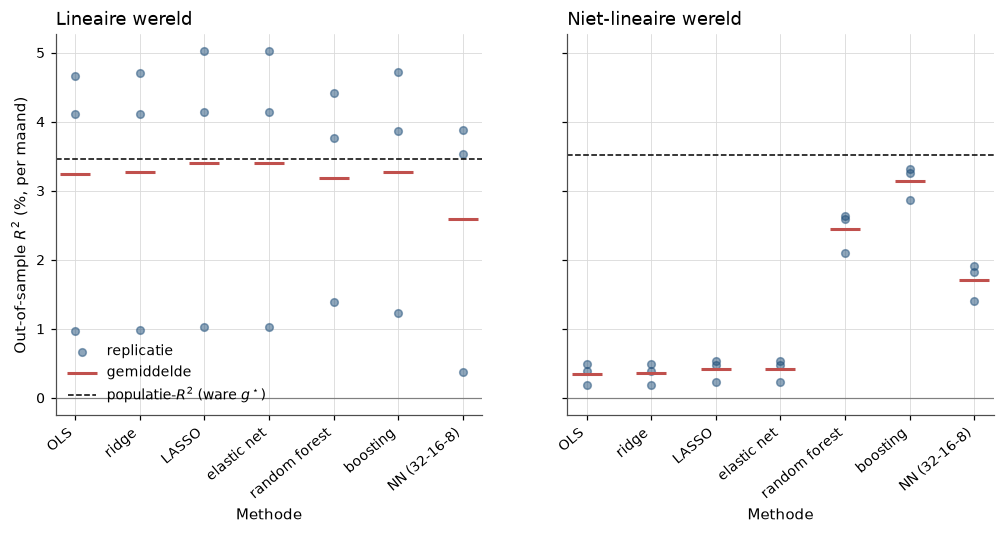

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (title, res) in zip(axes, [("Lineaire wereld", sim_linear),
                                   ("Niet-lineaire wereld", sim_nonlinear)]):
    models = [c for c in res.columns if c != "populatie"]
    pos = np.arange(len(models))
    for rep in res.index:
        ax.scatter(pos, res.loc[rep, models], color=hap.plotting.COLORS[0], alpha=0.5, s=25,
                   label="replicatie" if rep == 0 else None)
    ax.scatter(pos, res[models].mean(), color=hap.plotting.COLORS[1], marker="_", s=400,
               lw=2, label="gemiddelde")
    ax.axhline(res["populatie"].mean(), color="black", ls="--", lw=1,
               label="populatie-$R^2$ (ware $g^\\star$)")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(pos, models, rotation=40, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Methode")
axes[0].set_ylabel("Out-of-sample $R^2$ (%, per maand)")
axes[0].legend(loc="lower left")
plt.show()

:::{figure} #cel-machine-learning-sim-gkx
:label: fig-machine-learning-sim-gkx
:width: 95%

Out-of-sample $R^2$ in drie gesimuleerde panels per wereld. In de lineaire wereld halen alle
lineaire methoden bijna de populatiewaarde, en bomen en netwerk voegen niets toe. In de
niet-lineaire wereld blijven de lineaire methoden onder een half procent, terwijl boosting,
random forest en het netwerk een groot deel van de voorspelbaarheid vinden. De spreiding tussen
replicaties is groter dan de verschillen tussen de goede methoden.
:::

[](#fig-machine-learning-sim-gkx) geeft drie lessen. Ten eerste het patroon van GKX. In de
lineaire wereld liggen OLS, ridge, LASSO en elastic net binnen een half procentpunt van de
populatiewaarde; de bomen verliezen tot 0,6 procentpunt en het netwerk tot 1,1. In de niet-lineaire
wereld halen de lineaire methoden 0,2–0,5% tegen een populatiewaarde van 3,3–3,7%, boosting
2,9–3,3%, random forest 2,1–2,6% en het netwerk 1,4–1,9%. Ten tweede faalt OLS hier níet zoals in
GKX's Tabel 1: met $P = 40$ en 54.000 trainingsobservaties is $P/n$ te klein. GKX's $-3{,}46\%$ komt
van 920 voorspellers, en oefening [](#ex-machine-learning-2) laat OLS instorten zodra
$P/n_{\text{eff}}$ groeit. Ten derde het 2%-motief. De populatie-$R^2$ zelf loopt tussen de drie
replicaties van de lineaire wereld uiteen van 1,4% tot 5,0%, puur door ruis in 36 testmaanden, en
de verschillen tussen goede methoden zijn kleiner dan dat. Ook bij GKX zijn de verschillen tussen
bomen en netwerken volgens hun Diebold-Mariano-toetsen (Tabel 3) insignificant.

### (b) Martin en Nagel: voorspelbaarheid achteraf, niet vooraf

We simuleren [](#eq-machine-learning-mn) met $N = 500$ activa, $g = 1$, $\sigma = 1$ en een
oplopend aantal karakteristieken $J$, telkens 100 economieën. De beleggers hebben één periode
kasstromen gezien voordat de vijf perioden van de econometrist beginnen. Per economie berekenen we
de in-sample $F$-toets van een gepoolde OLS-regressie van rendementen op $\mathbf{X}$. Daarnaast de
real-time out-of-sample $R^2$ van een econometrist die elke periode OLS schat op de rendementen tot
dan toe, en van een die een ridge met de prior van de beleggers gebruikt.

In [8]:
def martin_nagel_economy(rng, n_assets, n_char, n_periods=5, burn_in=1, g=1.0, sigma=1.0):
    """One economy: in-sample F-test p-value, IS R^2, real-time OOS R^2 (OLS and ridge)."""
    X = rng.normal(size=(n_assets, n_char))
    theta = rng.normal(scale=np.sqrt(g / n_char), size=n_char)
    Y = X @ theta + sigma * rng.normal(size=(burn_in + n_periods, n_assets))
    lam = sigma**2 * n_char / g
    w, V = np.linalg.eigh(X.T @ X)                     # diagonalise X'X once
    XV = X @ V
    R, cum = np.empty_like(Y), np.zeros(n_char)
    for t in range(burn_in + n_periods):
        R[t] = Y[t] - XV @ (cum / (t * w + lam))       # payoff minus price, eq. (mn)
        cum += XV.T @ Y[t]
    R = R[burn_in:]
    coef = XV.T @ R.mean(axis=0) / w                    # pooled OLS
    rss1, rss0 = np.sum((R - XV @ coef) ** 2), np.sum(R**2)
    dof = n_assets * n_periods - n_char
    p_value = stats.f.sf(((rss0 - rss1) / n_char) / (rss1 / dof), n_char, dof)
    sse_ols = sse_ridge = sst = 0.0
    cum_r = np.zeros(n_char)
    for t in range(n_periods):
        if t >= 1:
            sse_ols += np.sum((R[t] - XV @ (cum_r / (t * w))) ** 2)
            sse_ridge += np.sum((R[t] - XV @ (cum_r / (t * w + lam))) ** 2)
            sst += np.sum(R[t] ** 2)
        cum_r += XV.T @ R[t]
    return p_value, 1 - rss1 / rss0, 1 - sse_ols / sst, 1 - sse_ridge / sst


n_assets, n_economies = 500, 100
mn_rows = []
for n_char in [10, 25, 50, 100, 200, 300, 400]:
    draws = np.array([martin_nagel_economy(rng, n_assets, n_char) for _ in range(n_economies)])
    mn_rows.append({
        "J/N": n_char / n_assets,
        "ongeleerd deel (1e periode)": 1 / (1 + n_assets / n_char),
        "verwerping F-toets (5%)": np.mean(draws[:, 0] < 0.05),
        "IS R2 min nul-R2 (%)": 100 * (draws[:, 1].mean() - n_char / (n_assets * 5)),
        "OOS R2 OLS (%, mediaan)": 100 * np.median(draws[:, 2]),
        "OOS R2 ridge (%, mediaan)": 100 * np.median(draws[:, 3]),
        "fractie OOS R2 ridge > 0": np.mean(draws[:, 3] > 0),
    })
mn_table = pd.DataFrame(mn_rows).set_index("J/N")
mn_table.round(3)

,ongeleerd deel (1e periode),verwerping F-toets (5%),IS R2 min nul-R2 (%),"OOS R2 OLS (%, mediaan)","OOS R2 ridge (%, mediaan)",fractie OOS R2 ridge > 0
J/N,,,,,,
0.02,0.020,0.20,0.152,-1.790,-1.732,0.0
0.05,0.048,0.31,0.380,-4.674,-4.389,0.0
0.10,0.091,0.54,0.769,-8.945,-7.669,0.0
0.20,0.167,0.55,1.089,-16.918,-12.664,0.0
0.40,0.286,0.55,1.491,-29.070,-16.677,0.0
0.60,0.375,0.39,1.114,-40.279,-18.426,0.0
0.80,0.444,0.15,0.602,-49.999,-19.210,0.0


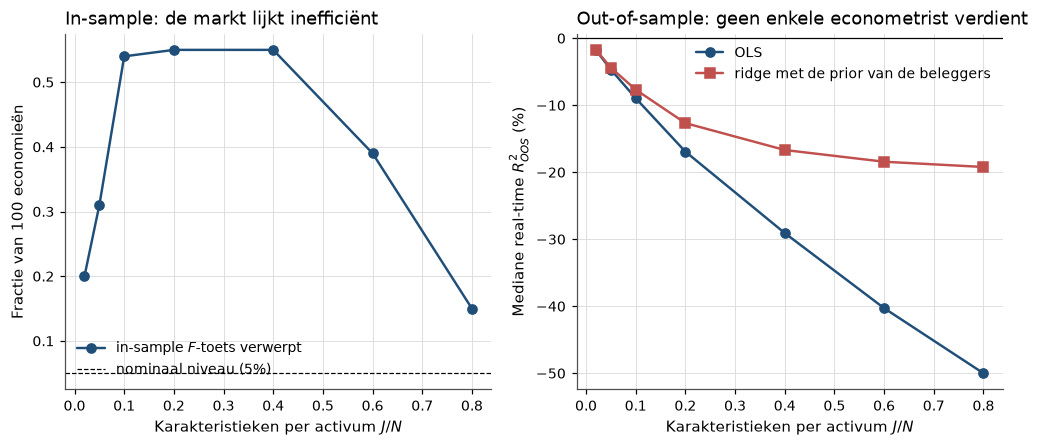

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(mn_table.index, mn_table["verwerping F-toets (5%)"], marker="o",
             label="in-sample $F$-toets verwerpt")
axes[0].axhline(0.05, color="black", ls="--", lw=0.8, label="nominaal niveau (5%)")
axes[0].set_xlabel("Karakteristieken per activum $J/N$")
axes[0].set_ylabel("Fractie van 100 economieën")
axes[0].set_title("In-sample: de markt lijkt inefficiënt")
axes[0].legend()
axes[1].plot(mn_table.index, mn_table["OOS R2 OLS (%, mediaan)"], marker="o", label="OLS")
axes[1].plot(mn_table.index, mn_table["OOS R2 ridge (%, mediaan)"], marker="s",
             label="ridge met de prior van de beleggers")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Karakteristieken per activum $J/N$")
axes[1].set_ylabel("Mediane real-time $R^2_{OOS}$ (%)")
axes[1].set_title("Out-of-sample: geen enkele econometrist verdient")
axes[1].legend()
plt.show()

:::{figure} #cel-machine-learning-sim-mn
:label: fig-machine-learning-sim-mn
:width: 95%

Beleggers die optimaal leren, prijzen in elke gesimuleerde economie rationeel. Toch verwerpt
de in-sample $F$-toets de nulhypothese van geen voorspelbaarheid veel vaker dan 5%, terwijl
geen enkele real-time voorspeller, ook niet één met de juiste prior, een positieve
out-of-sample $R^2$ haalt.
:::

De tabel en [](#fig-machine-learning-sim-mn) laten het mechanisme zien. Het ongeleerde deel van
het signaal groeit van 2% bij $J/N = 0{,}02$ tot 44% bij $J/N = 0{,}8$. De in-sample $R^2$ ligt tot
anderhalf procentpunt boven wat $J$ regressoren onder de nulhypothese mechanisch opleveren. De
$F$-toets verwerpt in 20% van de economieën bij $J/N = 0{,}02$ en in 55% bij $J/N$ tussen 0,1 en
0,4, terwijl het nominale niveau 5% is. Bij $J/N = 0{,}8$ zakt dat naar 15%, omdat de toets dan
$J$ vrijheidsgraden moet betalen; dat is een eigenschap van onze toets, niet van het mechanisme.
Out-of-sample is het beeld eenduidig. De mediane $R^2$ loopt voor de OLS-econometrist van $-1{,}8\%$
naar $-50\%$ en voor de ridge-econometrist van $-1{,}7\%$ naar $-19\%$. In geen enkele van de 700
economieën is de ridge-$R^2$ positief.
Ook de ridge-econometrist, die de prior kent, verliest: door het bijleren van de beleggers is de
"misprijzing" van gisteren niet die van vandaag. Daarom rapporteren GKX, KNS en de replicatie
hieronder uitsluitend out-of-sample.

### (c) Double descent en de deugd van complexiteit

Tot slot een tijdreeksversie in de geest van Kelly, Malamud en Zhou. De ware verwachte premie
is een niet-lineaire functie van 15 voorspellers (een som van 4.000 sinusfeatures), met een
populatie-$R^2$ van 5% per maand. Een onderzoeker heeft $T = 120$ maanden en benadert de functie
met $P$ willekeurige features $\sin(2\mathbf{w}_k'\mathbf{x}_t/\sqrt{15})$. Hij schat met de
kleinste-normregressie ("ridgeless", die ook voor $P > T$ bestaat) of met een kleine ridge, en
we evalueren op 1.000 nieuwe maanden: de $R^2$ en de Sharpe-ratio van de timingstrategie
$\hat r_{t+1} \cdot r_{t+1}$. Het 2%-motief zit in de keuze van $T$: tien jaar maanddata.

In [10]:
n_pred, t_train, t_test, n_true, p_max, n_rep_kmz = 15, 120, 1000, 4000, 1200, 50
w_true = rng.normal(size=(n_true, n_pred))
b_true = rng.normal(size=n_true)


def premium(x):
    return np.sin(2 * x @ w_true.T / np.sqrt(n_pred)) @ b_true / np.sqrt(n_true)


x_test = rng.normal(size=(t_test, n_pred))
mu_test = premium(x_test)
noise_sd = mu_test.std() * np.sqrt(0.95 / 0.05)                 # population R^2 = 5%
complexity = np.array([0.1, 0.25, 0.5, 0.75, 0.9, 1.0, 1.1, 1.5, 2, 3, 5, 10])
kmz = {k: np.zeros((n_rep_kmz, len(complexity))) for k in
       ["R2 ridgeless", "R2 ridge", "SR ridgeless", "SR ridge"]}
for rep in range(n_rep_kmz):
    W = rng.normal(size=(p_max, n_pred))
    x_train = rng.normal(size=(t_train, n_pred))
    y_train = premium(x_train) + noise_sd * rng.normal(size=t_train)
    y_test = mu_test + noise_sd * rng.normal(size=t_test)
    S_train = np.sin(2 * x_train @ W.T / np.sqrt(n_pred))
    S_test = np.sin(2 * x_test @ W.T / np.sqrt(n_pred))
    for k, c in enumerate(complexity):
        P = int(round(c * t_train))
        A, B = S_train[:, :P] / np.sqrt(P), S_test[:, :P] / np.sqrt(P)
        betas = {"ridgeless": np.linalg.lstsq(A, y_train, rcond=None)[0],       # min-norm
                 "ridge": A.T @ np.linalg.solve(A @ A.T + 0.1 * t_train * np.eye(t_train), y_train)}
        for name, beta in betas.items():
            forecast = B @ beta
            kmz[f"R2 {name}"][rep, k] = oos_r2(y_test, forecast)
            kmz[f"SR {name}"][rep, k] = hap.sharpe(pd.Series(forecast * y_test))

kmz_table = pd.DataFrame({"P/T": complexity,
                          "R2 ridgeless (mediaan, %)": 100 * np.median(kmz["R2 ridgeless"], 0),
                          "R2 ridge (mediaan, %)": 100 * np.median(kmz["R2 ridge"], 0),
                          "Sharpe ridgeless": kmz["SR ridgeless"].mean(0),
                          "Sharpe ridge": kmz["SR ridge"].mean(0)}).set_index("P/T")
kmz_table.round(3)

,"R2 ridgeless (mediaan, %)","R2 ridge (mediaan, %)",Sharpe ridgeless,Sharpe ridge
P/T,,,,
0.10,-8.848,-0.575,0.062,0.061
0.25,-29.309,-0.337,0.034,0.043
0.50,-99.134,-0.095,0.015,0.062
0.75,-282.323,-0.051,0.013,0.075
0.90,-847.356,0.006,0.021,0.085
1.00,-14541.674,-0.025,-0.002,0.077
1.10,-1030.142,0.042,-0.012,0.089
1.50,-223.592,0.048,0.031,0.108
2.00,-118.960,0.049,0.050,0.111


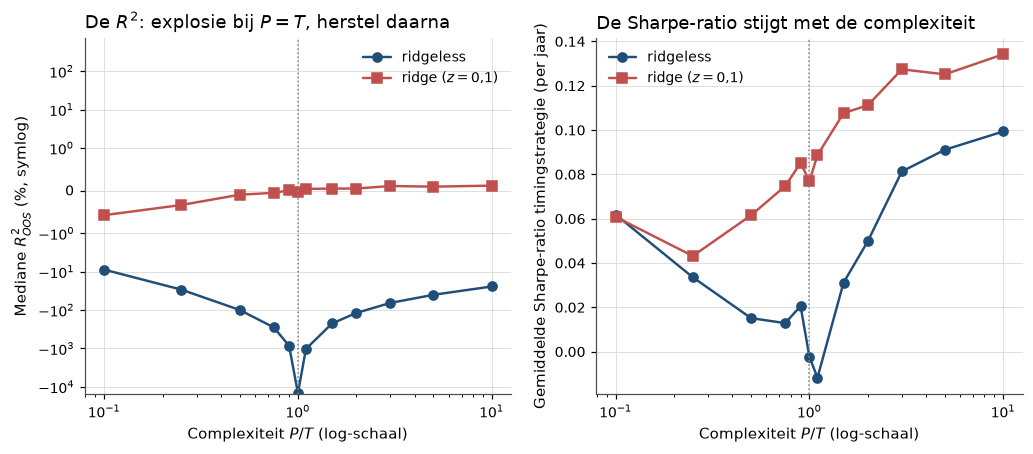

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(complexity, kmz_table["R2 ridgeless (mediaan, %)"], marker="o", label="ridgeless")
axes[0].plot(complexity, kmz_table["R2 ridge (mediaan, %)"], marker="s", label="ridge ($z = 0{,}1$)")
axes[0].axvline(1, color="grey", ls=":", lw=1)
axes[0].set_xscale("log")
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_xlabel("Complexiteit $P/T$ (log-schaal)")
axes[0].set_ylabel("Mediane $R^2_{OOS}$ (%, symlog)")
axes[0].set_title("De $R^2$: explosie bij $P = T$, herstel daarna")
axes[0].legend()
axes[1].plot(complexity, kmz_table["Sharpe ridgeless"], marker="o", label="ridgeless")
axes[1].plot(complexity, kmz_table["Sharpe ridge"], marker="s", label="ridge ($z = 0{,}1$)")
axes[1].axvline(1, color="grey", ls=":", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("Complexiteit $P/T$ (log-schaal)")
axes[1].set_ylabel("Gemiddelde Sharpe-ratio timingstrategie (per jaar)")
axes[1].set_title("De Sharpe-ratio stijgt met de complexiteit")
axes[1].legend()
plt.show()

:::{figure} #cel-machine-learning-sim-kmz
:label: fig-machine-learning-sim-kmz
:width: 95%

Double descent in een gesimuleerde markt-timingstudie met tien jaar data. De ridgeless $R^2$
stort in bij $P = T$ en herstelt daarna, zonder positief te worden. De ridge-$R^2$ blijft binnen
een half procentpunt van nul, maar de Sharpe-ratio van de ridge-timingstrategie stijgt vrijwel
monotoon met het aantal parameters, ook ver voorbij $P = T$.
:::

In [](#fig-machine-learning-sim-kmz) zakt de mediane ridgeless $R^2$ bij $P = T$ tot ruim
$-14.000\%$: de interpolerende regressie voorspelt dan met gigantische uitslagen. Bij $P/T = 10$ is
dat hersteld tot $-24\%$. Met ridge ligt de $R^2$ tussen $-0{,}6\%$ en $+0{,}1\%$, terwijl de
Sharpe-ratio van de timingstrategie stijgt van 0,06 bij $P/T = 0{,}1$ tot 0,13 bij $P/T = 10$. De
ridgeless Sharpe zakt rond $P = T$ naar nul en stijgt daarna tot 0,10. De niveaus zijn laag,
want tien jaar data is weinig, maar het patroon is dat van Kelly, Malamud en Zhou.

Een negatieve of verwaarloosbare $R^2$ en een stijgende Sharpe-ratio zijn geen tegenspraak.
De $R^2$ straft de *schaal* van de voorspelling, de Sharpe-ratio beloont het *teken* en de
correlatie met het rendement. Dat is [](#eq-voorspelbaarheid-ct) opnieuw: kleine
voorspelbaarheid kan economisch groot zijn, ook met veel meer parameters dan maanden.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Gu, Kelly & Xiu, *Empirical Asset Pricing via Machine Learning*, Review of Financial
Studies 2020 {cite}`GuKellyXiu2020`; Kozak, Nagel & Santosh, *Shrinking the Cross-Section*,
Journal of Financial Economics 2020 {cite}`KozakNagelSantosh2020`.

**Wat.** (1) De vergelijking van GKX's Tabel 1 en 7: OOS-$R^2$ volgens
[](#eq-machine-learning-oos) van OLS, ridge, LASSO, random forest en gradient boosting, plus
de Sharpe-ratio van een long-short-portefeuille op de voorspellingen. (2) Het KNS-resultaat
dat een L2-gekrompen SDF met weinig hoofdcomponenten de cross-sectie out-of-sample beter prijst
dan een even sparse SDF in karakteristieken.

**Data hier.** Open Source Asset Pricing {cite}`ChenZimmermann2022`, 212 maandelijkse
long-short signaalportefeuilles, via `hap.data.osap()`. (1) Voorspellen welk *signaal*
volgende maand goed doet, uit eigen vertraagde rendementen en die van alle signalen samen
(factor momentum en timing, {cite:t}`EhsaniLinnainmaa2022`), 1963–2024, expanding window met
voorspellingen vanaf 1990. (2) De 158 signalen met een volledige reeks 1975–2024; schatten
op 1975–2004, testen op 2005–2024.

**Verschil met het origineel.** Dit is geen replicatie van GKX: er zijn geen gratis
aandeeldata, dus we voorspellen portefeuilles van signalen en geen aandelen, met zes
voorspellers in plaats van 920. KNS gebruiken karakteristiekportefeuilles van individuele
aandelen met hun eigen constructie; wij gebruiken de gepubliceerde OSAP-portefeuilles, die
niet op volatiliteit geschaald zijn (wij standaardiseren ze op het schattingsblok). De
signaalverzameling zelf is achteraf gekozen (McLean-Pontiff), zodat ook "out-of-sample"
voorspellingen van vóór de publicatie van een signaal kennis van later bevatten.

**Verwachte afwijking.** (1) Niet-lineaire methoden verslaan OLS out-of-sample over 1990–2024,
maar met een kleine $R^2$-winst: tienden van een procentpunt, niet de verdubbeling van GKX.
Na 2005 zijn de winsten zwakker. (2) In de KNS-maatstaf (out-of-sample cross-sectionele $R^2$)
verslaat een L2-SDF met een handvol hoofdcomponenten een even sparse SDF in signaalruimte.
Het teken van beide rangordes moet kloppen. Wijkt het af, dan ligt de fout eerder in de code
dan in de data.
```

### (1) Welk signaal doet het volgende maand goed?

Per signaal $i$ en maand $t$ zijn er zes voorspellers: het eigen rendement in maand $t$, het
eigen gemiddelde over $t-11$ tot $t-1$ en over $t-35$ tot $t-12$, de eigen twaalfmaandsvolatiliteit,
en het gelijkgewogen rendement van alle signalen in maand $t$ en over $t-11$ tot $t-1$. Het doel is
$r_{i,t+1}$, gepoold over signalen zoals GKX over aandelen poolen. Om de vijf jaar (1990, …, 2020)
schatten we opnieuw. De vijf jaar ervoor zijn validatie, alles daarvoor (vanaf 1963) training, en
de vijf jaar erna test.

In [12]:
osap = hap_data.osap().loc["1963":].astype("float64")
ew = osap.mean(axis=1)


def broadcast(series):
    return pd.DataFrame(np.repeat(series.to_numpy()[:, None], osap.shape[1], axis=1),
                        index=osap.index, columns=osap.columns)


features = {
    "r_t": osap,
    "r_t-11:t-1": osap.shift(1).rolling(11, min_periods=9).mean(),
    "r_t-35:t-12": osap.shift(12).rolling(24, min_periods=18).mean(),
    "vol_12m": osap.rolling(12, min_periods=9).std(),
    "ew_t": broadcast(ew),
    "ew_t-11:t-1": broadcast(ew.shift(1).rolling(11).mean()),
}
panel = pd.concat({k: v.stack() for k, v in features.items()}, axis=1)
panel["y"] = osap.shift(-1).stack()
panel = panel.dropna().rename_axis(["date", "signal"])
feature_names = list(features)
print(f"{len(panel):,} signaal-maanden, {panel.index.get_level_values('signal').nunique()} signalen, "
      f"{panel.index.get_level_values('date').min():%Y-%m} t/m {panel.index.get_level_values('date').max():%Y-%m}")

134,518 signaal-maanden, 212 signalen, 1965-06 t/m 2024-11


In [13]:
REAL_MODELS = {
    "OLS": (lambda h: LinearRegression(), [None]),
    "ridge": (lambda h: Ridge(alpha=h), [1e-1, 1e1, 1e3]),
    "LASSO": (lambda h: Lasso(alpha=h), [1e-5, 1e-4, 1e-3]),
    "random forest": (lambda h: RandomForestRegressor(
        n_estimators=50, max_depth=h, max_features=0.5, max_samples=0.3,
        min_samples_leaf=200, n_jobs=1, random_state=0), [2, 4]),
    "boosting": (lambda h: HistGradientBoostingRegressor(
        max_depth=h, learning_rate=0.05, max_iter=100, min_samples_leaf=500,
        random_state=0), [1, 2]),
}
dates = panel.index.get_level_values("date")
y_all = panel["y"].to_numpy()
forecasts = []
for start in range(1990, 2025, 5):
    train = dates < pd.Timestamp(start - 5, 1, 1)
    valid = (dates >= pd.Timestamp(start - 5, 1, 1)) & (dates < pd.Timestamp(start, 1, 1))
    test = (dates >= pd.Timestamp(start, 1, 1)) & (dates < pd.Timestamp(start + 5, 1, 1))
    raw = panel[feature_names].to_numpy()
    Z = (raw - raw[train].mean(axis=0)) / raw[train].std(axis=0)   # training moments only
    block = panel.loc[test, ["y"]].copy()
    for name, (make, grid) in REAL_MODELS.items():
        fits = [make(h).fit(Z[train], y_all[train]) for h in grid]
        best = max(fits, key=lambda m: oos_r2(y_all[valid], m.predict(Z[valid])))
        block[name] = best.predict(Z[test])
    past_mean = panel.loc[train | valid].groupby(level="signal")["y"].mean()
    block["historisch gemiddelde"] = (past_mean.reindex(block.index.get_level_values("signal"))
                                      .fillna(0.0).to_numpy())
    forecasts.append(block)
forecasts = pd.concat(forecasts)
forecast_names = list(REAL_MODELS) + ["historisch gemiddelde"]
print(f"{len(forecasts):,} out-of-sample voorspellingen, "
      f"{forecasts.index.get_level_values('date').min():%Y-%m} t/m "
      f"{forecasts.index.get_level_values('date').max():%Y-%m}")

86,000 out-of-sample voorspellingen, 1990-01 t/m 2024-11


We rapporteren de GKX-$R^2$, de $R^2$ ten opzichte van het historische gemiddelde per signaal
([](#eq-voorspelbaarheid-oos)) en de aangepaste Diebold-Mariano-$t$ tegen OLS (positief is beter).
Daarnaast de Sharpe-ratio van een portefeuille die maandelijks de 20% signalen met de hoogste
voorspelling koopt en de 20% met de laagste verkoopt, met standaardfout
$\sqrt{(1 + SR_m^2/2)/T}\cdot\sqrt{12}$ ($SR_m$ maandelijks, i.i.d.).

In [14]:
def long_short(block, name, q=0.2):
    rank = block[name].groupby(level="date").rank(pct=True)
    y = block["y"]
    return (y[rank > 1 - q].groupby(level="date").mean()
            - y[rank <= q].groupby(level="date").mean())


def evaluate(block):
    rows = {}
    err_ols = (block["y"] - block["OLS"]) ** 2
    err_hist = (block["y"] - block["historisch gemiddelde"]) ** 2
    for name in forecast_names:
        err = (block["y"] - block[name]) ** 2
        d = (err_ols - err).groupby(level="date").mean()                 # GKX eq. (20)
        dm = hap.newey_west(d, pd.DataFrame(index=d.index), lags=6)
        ls = long_short(block, name)
        sr_m = ls.mean() / ls.std()
        rows[name] = {
            "R2 GKX (%)": 100 * oos_r2(block["y"], block[name]),
            "R2 t.o.v. hist. gem. (%)": 100 * (1 - err.sum() / err_hist.sum()),
            "DM-t tegen OLS": np.nan if name == "OLS" else dm.tvalues.iloc[0],
            "Sharpe L-S": hap.sharpe(ls),
            "SE Sharpe": np.sqrt((1 + sr_m**2 / 2) / len(ls)) * np.sqrt(12),
        }
    return pd.DataFrame(rows).T


periods = {"1990-2024": ("1990", "2024"), "1990-2004": ("1990", "2004"), "2005-2024": ("2005", "2024")}
real1 = pd.concat({label: evaluate(forecasts.loc[a:b]) for label, (a, b) in periods.items()})
equal_weight = {label: hap.sharpe(forecasts.loc[a:b, "y"].groupby(level="date").mean())
                for label, (a, b) in periods.items()}
print("Sharpe van alle signalen gelijkgewogen:", {k: round(v, 2) for k, v in equal_weight.items()})
real1.round(3)

Sharpe van alle signalen gelijkgewogen: {'1990-2024': np.float64(1.89), '1990-2004': np.float64(2.4), '2005-2024': np.float64(1.55)}


R2 GKX (%)  R2 t.o.v. hist. gem. (%)  \
1990-2024 OLS                         1.996                     0.749   
          ridge                       2.002                     0.755   
          LASSO                       2.059                     0.813   
          random forest               2.357                     1.115   
          boosting                    2.335                     1.093   
          historisch gemiddelde       1.256                     0.000   
1990-2004 OLS                         3.111                     0.712   
          ridge                       3.111                     0.712   
          LASSO                       3.113                     0.714   
          random forest               3.858                     1.477   
          boosting                    3.803                     1.421   
          historisch gemiddelde       2.416                     0.000   
2005-2024 OLS                         1.097                     0.854   
          ridge                       1.111                     0.867   
          LASSO                       1.222                     0.978   
          random forest               1.025                     0.782   
          boosting                    1.062                     0.818   
          historisch gemiddelde       0.246                     0.000   

                                 DM-t tegen OLS  Sharpe L-S  SE Sharpe  
1990-2024 OLS                               NaN       0.778      0.173  
          ridge                           1.741       0.779      0.173  
          LASSO                           0.438       0.774      0.173  
          random forest                   0.712       0.776      0.173  
          boosting                        0.671       0.763      0.173  
          historisch gemiddelde          -0.973       1.319      0.177  
1990-2004 OLS                               NaN       0.851      0.270  
          ridge                           0.289       0.851      0.270  
          LASSO                           0.517       0.849      0.270  
          random forest                   0.898       0.938      0.271  
          boosting                        0.795       0.869      0.271  
          historisch gemiddelde          -0.515       1.569      0.280  
2005-2024 OLS                               NaN       0.776      0.232  
          ridge                           1.783       0.777      0.232  
          LASSO                           0.429       0.767      0.232  
          random forest                  -0.137       0.678      0.231  
          boosting                       -0.080       0.724      0.231  
          historisch gemiddelde          -1.160       1.159      0.235

De tabel bevestigt beide rangordes uit het replicatieblok, en laat zien hoe klein ze zijn. Over
1990–2024 halen random forest en boosting een GKX-$R^2$ van 2,36% en 2,34%, tegen 2,00% voor OLS:
ruim een derde procentpunt winst. Dat de $R^2$ veel hoger ligt dan bij GKX, komt doordat de
signalen gemiddeld een positieve premie hebben. Het historische gemiddelde per signaal haalt al
1,26%, en tegen die maatstaf verdienen de bomen 1,1% en OLS 0,75%. De Diebold-Mariano-$t$ van de
bomen tegen OLS is 0,7: het verschil is statistisch niet van nul te onderscheiden. De hele winst zit
vóór 2005 (3,86% tegen 3,11%). Na 2005 vallen random forest (1,03%) en boosting (1,06%) onder OLS
(1,10%), en doet alleen LASSO (1,22%) het iets beter.

Economisch is het beeld nog soberder. De long-short-portefeuille op de voorspellingen heeft voor
elke methode een Sharpe-ratio rond 0,78 (standaardfout 0,17). Sorteren op het historische
gemiddelde geeft 1,32, en alle signalen gelijkgewogen houden 1,89. Timing binnen de zoo voegt dus
weinig toe aan het dragen van de gemiddelde anomaliepremie. Dat weerlegt GKX niet (duizenden
aandelen en 920 voorspellers tegen onze tweehonderd portefeuilles en zes voorspellers), maar past
bij Avramov, Cheng en Metzker: waar de handel goedkoop is, is de extra voorspelbaarheid klein. Het
dalende niveau van álle getallen na 2005, ook van het gelijkgewogen signaal (Sharpe 2,40 vóór en
1,55 na 2005), is het publicatieverval uit [](#06-34-factor-zoo).

### (2) Een gekrompen SDF op 158 signalen

We standaardiseren de 158 signalen met hun standaarddeviatie over 1975–2004 en schatten
$\hat{\mathbf{b}}$ uit [](#eq-machine-learning-kns) op dat blok. $\kappa$ kiezen we met drievoudige
cross-validatie over aaneengesloten blokken van tien jaar, op de cross-sectionele $R^2$. Daarna
vergelijken we twee sparse varianten met dezelfde L2-straf $\gamma$:

- *sparse in hoofdcomponenten*: alleen de eerste $K$ PC's van $\boldsymbol{\Sigma}$ krijgen een
  gewicht $\bar\mu_{P,j}/(\lambda_j + \gamma)$ (deel 3 van
  [](#prop-machine-learning-kns));
- *sparse in signalen*: de elastic net uit deel 2 van [](#prop-machine-learning-kns) met
  oplopende L1-straf, geschreven als LASSO op uitgebreide data $\lVert(\boldsymbol{\Sigma}^{-1/2}\bar{\boldsymbol{\mu}}, \mathbf{0}) - (\boldsymbol{\Sigma}^{1/2}, \sqrt{\gamma}\mathbf{I})\mathbf{b}\rVert^2$.

Alles wordt geëvalueerd op 2005–2024: de cross-sectionele $R^2$ met testmomenten en de
Sharpe-ratio van de SDF-portefeuille $\hat{\mathbf{b}}'\mathbf{F}_{t+1}$.

In [15]:
signals = hap_data.osap().loc["1975":"2024"].astype("float64")
signals = signals.loc[:, signals.notna().all()]
scale = signals.loc[:"2004"].std()
F_est, F_test = (signals.loc[:"2004"] / scale).to_numpy(), (signals.loc["2005":] / scale).to_numpy()
T_est, H = F_est.shape


def moments(F):
    return F.mean(axis=0), np.atleast_2d(np.cov(F, rowvar=False))


def cs_r2(b, F):
    """KNS cross-sectional R^2 of the SDF b on the moments of F."""
    mu, S = moments(F)
    e = mu - S @ b
    return 1 - e @ e / (mu @ mu)


def l2_sdf(F, kappa):
    mu, S = moments(F)
    gamma = np.trace(S) / (kappa**2 * len(F))
    return np.linalg.solve(S + gamma * np.eye(S.shape[0]), mu), gamma


kappas = np.logspace(-2, 1, 25)
folds = np.array_split(np.arange(T_est), 3)
cv = []
for kappa in kappas:
    scores = []
    for fold in folds:
        keep = np.ones(T_est, dtype=bool)
        keep[fold] = False
        scores.append(cs_r2(l2_sdf(F_est[keep], kappa)[0], F_est[fold]))
    cv.append(np.mean(scores))
kappa_star = kappas[int(np.argmax(cv))]
b_l2, gamma_star = l2_sdf(F_est, kappa_star)
mu_est, S_est = moments(F_est)

ols_sdf = np.linalg.solve(S_est, mu_est)
kns_table = pd.DataFrame({
    "cs-R2 in-sample": [cs_r2(ols_sdf, F_est), cs_r2(b_l2, F_est), np.nan],
    "cs-R2 OOS": [cs_r2(ols_sdf, F_test), cs_r2(b_l2, F_test), np.nan],
    "Sharpe in-sample": [hap.sharpe(pd.Series(F_est @ ols_sdf)), hap.sharpe(pd.Series(F_est @ b_l2)),
                         hap.sharpe(pd.Series(F_est.mean(axis=1)))],
    "Sharpe OOS": [hap.sharpe(pd.Series(F_test @ ols_sdf)), hap.sharpe(pd.Series(F_test @ b_l2)),
                   hap.sharpe(pd.Series(F_test.mean(axis=1)))],
}, index=["ongekrompen tangentportefeuille", f"L2-SDF (kappa = {kappa_star:.3f})",
          "alle signalen gelijkgewogen"])
kns_table.round(3)

,cs-R2 in-sample,cs-R2 OOS,Sharpe in-sample,Sharpe OOS
ongekrompen tangentportefeuille,1.000,-170.398,13.514,2.319
L2-SDF (kappa = 0.133),0.388,0.403,4.259,2.065
alle signalen gelijkgewogen,NaN,NaN,2.735,1.557


In [16]:
lam, Q = np.linalg.eigh(S_est)
order = np.argsort(lam)[::-1]
lam, Q = lam[order], Q[:, order]
mu_pc = Q.T @ mu_est

sparse_rows = []
for K in range(1, H + 1):                                        # sparse in PCs
    b_pc = np.zeros(H)
    b_pc[:K] = mu_pc[:K] / (lam[:K] + gamma_star)
    b = Q @ b_pc
    sparse_rows.append(("hoofdcomponenten", K, cs_r2(b, F_test), hap.sharpe(pd.Series(F_test @ b))))

w_eig, V_eig = np.linalg.eigh(S_est)                             # sparse in signals
S_half = V_eig @ np.diag(np.sqrt(w_eig)) @ V_eig.T
S_minus_half = V_eig @ np.diag(1 / np.sqrt(w_eig)) @ V_eig.T
X_aug = np.vstack([S_half, np.sqrt(gamma_star) * np.eye(H)])
y_aug = np.concatenate([S_minus_half @ mu_est, np.zeros(H)])
alpha_max = np.max(np.abs(X_aug.T @ y_aug)) / len(y_aug)
for alpha in alpha_max * np.logspace(-3, -0.01, 60):
    b = Lasso(alpha=alpha, fit_intercept=False, max_iter=20_000, tol=1e-6).fit(X_aug, y_aug).coef_
    if np.any(b != 0):
        sparse_rows.append(("signalen", int(np.sum(b != 0)), cs_r2(b, F_test),
                            hap.sharpe(pd.Series(F_test @ b))))
sparse = (pd.DataFrame(sparse_rows, columns=["ruimte", "K", "cs-R2 OOS", "Sharpe OOS"])
          .drop_duplicates(["ruimte", "K"]).sort_values(["ruimte", "K"]))
by_signal = sparse[sparse["ruimte"] == "signalen"].drop(columns="ruimte").set_index("K")
by_pc = sparse[sparse["ruimte"] == "hoofdcomponenten"].drop(columns="ruimte").set_index("K")
by_signal.join(by_pc, lsuffix=" (signalen)", rsuffix=" (PC's)").round(3)   # same K in both spaces

,cs-R2 OOS (signalen),Sharpe OOS (signalen),cs-R2 OOS (PC's),Sharpe OOS (PC's)
K,,,,
1,0.003,1.273,0.053,0.450
2,0.013,1.533,0.083,0.457
3,0.025,1.645,0.242,0.726
4,0.039,1.723,0.262,0.780
7,0.058,1.786,0.302,0.884
11,0.078,1.852,0.301,0.929
15,0.098,1.895,0.349,1.183
23,0.119,1.914,0.363,1.422
28,0.139,1.915,0.371,1.488


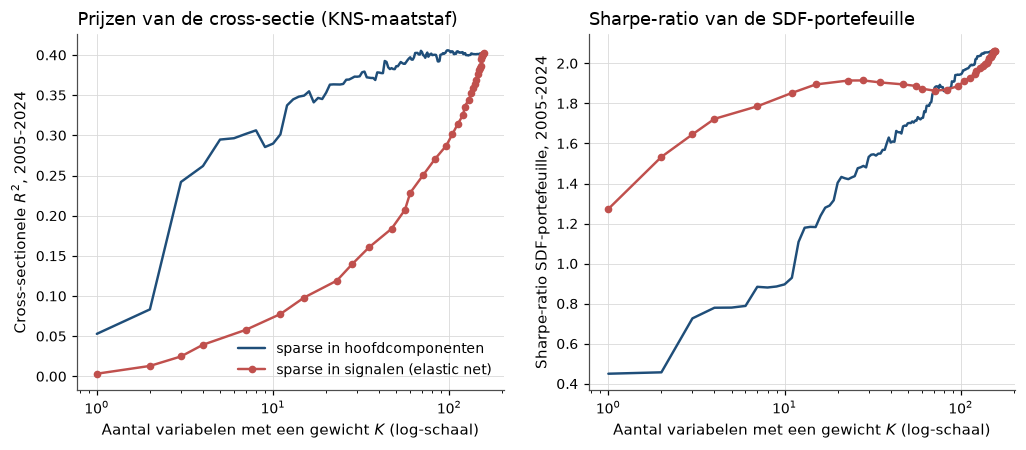

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for i, (space, label) in enumerate([("hoofdcomponenten", "sparse in hoofdcomponenten"),
                                    ("signalen", "sparse in signalen (elastic net)")]):
    part = sparse[sparse["ruimte"] == space]
    axes[0].plot(part["K"], part["cs-R2 OOS"], marker="o" if i else None, ms=4,
                 color=hap.plotting.COLORS[i], label=label)
    axes[1].plot(part["K"], part["Sharpe OOS"], marker="o" if i else None, ms=4,
                 color=hap.plotting.COLORS[i], label=label)
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Aantal variabelen met een gewicht $K$ (log-schaal)")
axes[0].set_ylabel("Cross-sectionele $R^2$, 2005-2024")
axes[0].set_title("Prijzen van de cross-sectie (KNS-maatstaf)")
axes[1].set_ylabel("Sharpe-ratio SDF-portefeuille, 2005-2024")
axes[1].set_title("Sharpe-ratio van de SDF-portefeuille")
axes[0].legend()
plt.show()

:::{figure} #cel-machine-learning-kns
:label: fig-machine-learning-kns
:width: 95%

Out-of-sample prestaties van sparse SDF's, geschat op 1975–2004 en getoetst op 2005–2024, met
dezelfde L2-straf. Links de KNS-maatstaf: met een handvol hoofdcomponenten prijst de SDF een
groot deel van de cross-sectie van 158 gemiddelden, terwijl een even sparse SDF in signalen daar
ver onder blijft. Rechts de Sharpe-ratio, waar de rangorde bij weinig variabelen omdraait.
:::

Eerst de L2-SDF zelf. Cross-validatie kiest $\kappa = 0{,}133$. De SDF prijst in-sample 39% van
de cross-sectie van 158 gemiddelden, en op 2005–2024 40%. De ongekrompen tangentportefeuille prijst
in-sample per constructie alles en out-of-sample niets ($R^2 = -170$): zo ziet de schattingsfout
in $\boldsymbol{\Sigma}^{-1}\bar{\boldsymbol{\mu}}$ eruit. De Sharpe-ratio's vertellen een ander
verhaal: 13,5 en 4,3 in-sample, 2,32 en 2,07 out-of-sample. De KNS-maatstaf vraagt of
$\hat{\mathbf{b}}$ *alle* gemiddelden verklaart, de Sharpe-ratio alleen of de ene portefeuille
$\hat{\mathbf{b}}'\mathbf{F}$ goed rendeert. Een Sharpe-ratio van 2,1 over 240 maanden heeft een
standaardfout van ongeveer 0,24. Het verschil tussen 2,32 en 2,07 is dus ruis, de daling van 4,3
naar 2,1 niet. Die daling mengt wel overfitting en het publicatieverval na 2005, en die twee kunnen
we met één splitsing niet scheiden.

Dan sparsiteit, in [](#fig-machine-learning-kns). In de KNS-maatstaf is de uitkomst die van het
replicatieblok. Vijf hoofdcomponenten halen een out-of-sample $R^2$ van 0,30, driekwart van de 0,40
van de volledige SDF. De elastic net in signaalruimte haalt met vier signalen 0,04, met vijftien
0,10 en met zestig 0,23. Sparsiteit in karakteristieken faalt, sparsiteit in hoofdcomponenten
werkt. In Sharpe-ratio draait de rangorde om: vier signalen geven 1,72, vijf PC's 0,78. De elastic
net kiest in-sample de signalen met de hoogste premie per eenheid risico. Die blijven na 2005
behoorlijk renderen, maar prijzen de andere 150 signalen niet. Voor een belegger die één portefeuille
zoekt, is dat een ander antwoord dan voor een onderzoeker die de SDF zoekt. De verwachting in het
replicatieblok ging over de tweede vraag en klopt. Het omgekeerde Sharpe-resultaat is een afwijking
van het KNS-verhaal die we laten staan.

## Wat er brak, en wat daarna kwam

**Wat machine learning verklaart.** Het maakte van de factor zoo een meetprobleem met een
oplossing. Honderden karakteristieken, in [](#06-34-factor-zoo) een bron van valse ontdekkingen,
worden onder shrinkage, selectie en validatie één voorspelling die out-of-sample standhoudt. Bij
GKX is dat een maandelijkse $R^2$ van 0,40% tegen $-3{,}46\%$ voor OLS, met een value-weighted
long-short Sharpe van 1,35. Kozak, Nagel en Santosh beschreven de SDF achter al die anomalieën met
een paar hoofdcomponenten, en Kelly, Pruitt en Su lazen karakteristieken als bèta's. In een vak
waar elk gemiddelde een fout van 2% draagt, is dat een aanzienlijke winst.

**Waar het breekt.** Niet in de voorspelling, maar in de vertaling naar winst en betekenis. De
netwerkportefeuilles van GKX draaien elke maand meer dan hun eigen omvang om (110–130%), en hun
equal-weighted Sharpe daalt van 2,45 naar 1,69 zodra de kleinste aandelen eruit gaan.
Avramov, Cheng en Metzker {cite}`AvramovChengMetzker2023` betogen dat de ML-winsten zich
concentreren in moeilijk verhandelbare aandelen en na economische restricties veel kleiner
worden. Hun getallen hebben we niet zelf nagelezen. In onze replicatie is de winst van niet-lineaire
methoden klein en na 2005 weg, en is de best prijzende sparse SDF niet de portefeuille met de
hoogste Sharpe-ratio. Martin en Nagel geven de
diepste barst: zelfs een perfect gemeten in-sample voorspelbaarheid zegt niets over efficiëntie
als beleggers moeten leren.

**Risico of vergissing?** Dezelfde voorspelling heeft twee lezingen. De Chicago-lezing: een netwerk dat
verwachte rendementen meet, meet risicopremies. Het meet ze beter omdat bèta's niet-lineair van
karakteristieken afhangen, en IPCA en de KNS-prior schrijven een groot deel inderdaad als
covariantie. De Yale-lezing: de sterkste voorspellers bij GKX zijn kortetermijn-
reversal, momentum, liquiditeit en volatiliteit. Dat is precies waar limits of arbitrage en
beleggersgedrag hun sporen achterlaten, en precies waar handelskosten de alfa opeten. Martin en
Nagel voegen een derde lezing toe die geen van beide kampen nodig heeft: leren. Wat de kampen zou
scheiden, is voorspelbaarheid na publicatie, op schaal en na kosten, in een markt waarin de
machines tegen elkaar handelen. Die data bestaan nog niet. Santa-Clara's praktijkmotief is hier
een directe waarschuwing: wie een netwerkvoorspelling koopt, moet weten of hij een beprijsd risico
draagt of denkt iets te weten wat de prijs niet wist.

**Wat er daarna kwam.** Wie wil weten *waarom* prijzen bewegen, kan in plaats van naar
informatie ook kijken naar wie de aandelen koopt:
[demand systems en inelastische markten](#06-36-inelastische-markten).

## Oefeningen

:::{exercise}
:label: ex-machine-learning-1

**Optimale krimp.** Stel $\mathbf{X}'\mathbf{X} = d\,\mathbf{I}$, $\mathbf{r} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$
met $\boldsymbol{\varepsilon} \sim N(0, \sigma^2\mathbf{I})$, en ridge-schatter $\hat b_j = z_j/(d + \lambda)$.

1. Laat zien dat $\E[(\hat b_j - \beta_j)^2] = \big(\lambda\beta_j/(d+\lambda)\big)^2 + \sigma^2 d/(d+\lambda)^2$
   en dat $\lambda^\star = \sigma^2/\beta_j^2$ dit minimaliseert.
2. Neem $d = 10$, $\sigma = 3$ en $\beta_j = 0{,}3$ (een signaal dat klein is ten opzichte van de ruis,
   zoals bij rendementen). Bereken $\lambda^\star$ en de verhouding van de verwachte kwadratische
   fout van ridge en OLS. Controleer met een Monte Carlo van 100.000 trekkingen.
3. Met welk getal vermenigvuldigt ridge hier de OLS-schatter? Wat zegt dat over de toy-keuze
   $\lambda = 10$?
:::

:::{solution} ex-machine-learning-1
:class: dropdown

**(1)** $z_j = d\beta_j + \mathbf{x}_j'\boldsymbol{\varepsilon}$ met $\Var(\mathbf{x}_j'\boldsymbol{\varepsilon}) = \sigma^2 d$.
Dus $\E[\hat b_j] = d\beta_j/(d+\lambda)$, bias $-\lambda\beta_j/(d+\lambda)$, variantie $\sigma^2 d/(d+\lambda)^2$.
De afgeleide van de som naar $\lambda$ is
$2d\,(\lambda\beta_j^2 - \sigma^2)/(d+\lambda)^3$, die nul is bij $\lambda^\star = \sigma^2/\beta_j^2$,
negatief daaronder en positief daarboven.

**(2) en (3)**

In [18]:
d, sigma, beta = 10.0, 3.0, 0.3
lam_star = sigma**2 / beta**2
mse = lambda lam: (lam * beta / (d + lam)) ** 2 + sigma**2 * d / (d + lam) ** 2
z_draws = d * beta + sigma * np.sqrt(d) * rng.normal(size=100_000)
mc = {lam: np.mean((z_draws / (d + lam) - beta) ** 2) for lam in (0.0, lam_star)}
print(f"lambda* = {lam_star:.0f}, krimpfactor d/(d+lambda*) = {d / (d + lam_star):.3f}")
print(f"MSE OLS   : analytisch {mse(0):.4f}, Monte Carlo {mc[0.0]:.4f}")
print(f"MSE ridge : analytisch {mse(lam_star):.4f}, Monte Carlo {mc[lam_star]:.4f}")
print(f"verhouding ridge/OLS = {mse(lam_star) / mse(0):.3f}")

lambda* = 100, krimpfactor d/(d+lambda*) = 0.091
MSE OLS   : analytisch 0.9000, Monte Carlo 0.8972
MSE ridge : analytisch 0.0818, Monte Carlo 0.0818
verhouding ridge/OLS = 0.091


Bij $\sigma^2/\beta^2 = 100$ is de optimale krimpfactor $10/110 \approx 0{,}09$: ridge houdt
maar 9% van de OLS-schatting over, en verlaagt daarmee de verwachte kwadratische fout met ruim
90% (van 0,90 naar 0,08). De toy-keuze $\lambda = 10$ (krimp met de helft) is naar deze maatstaf
nog voorzichtig. Bij signaal-ruisverhoudingen zoals die van rendementen is harde krimp geen
technisch detail maar de kern van de schatter.
:::

:::{exercise}
:label: ex-machine-learning-2

**Wanneer OLS instort.** Herhaal simulatie (a) in de lineaire wereld met alleen de lineaire
methoden (OLS, ridge, LASSO), maar maak de steekproef kort: $T = 48$ maanden (training 1–30,
validatie 31–39, test 40–48) en voeg 60 karakteristieken zonder voorspellende waarde toe, zodat
$P = 160$. Doe drie replicaties. Hoe verhouden de OLS-$R^2$, de ridge-$R^2$ en de
populatie-$R^2$ zich, en hoe verhoudt dat zich tot GKX's $-3{,}46\%$?
:::

:::{solution} ex-machine-learning-2
:class: dropdown

`simulate_gkx` met `n_char=80` levert 80 gerankte karakteristieken en $P = 160$ voorspellers;
alleen de eerste drie tellen mee in $g^\star$.

In [19]:
linear_models = {k: SIM_MODELS[k] for k in ["OLS", "ridge", "LASSO"]}
month = np.repeat(np.arange(48), 500)
train, valid, test = month < 30, (month >= 30) & (month < 39), month >= 39
rows = []
for rep in range(3):
    Z, y, g = simulate_gkx(rng, nonlinear=False, n_stocks=500, n_months=48, n_char=80)
    row = {"populatie": oos_r2(y[test], g[test])}
    row.update(fit_validate(linear_models, Z, y, train, valid, test))
    rows.append(row)
(100 * pd.DataFrame(rows).rename_axis("replicatie")).round(2)

,populatie,OLS,ridge,LASSO
replicatie,,,,
0,5.41,-16.26,-6.99,-1.76
1,3.06,0.52,1.01,2.15
2,6.62,0.11,0.86,1.21


Met 15.000 trainingsobservaties en 160 voorspellers lijkt $P/n$ klein, maar de gemeenschappelijke
schok en de persistentie van de karakteristieken maken $n_{\text{eff}}$ veel kleiner. In de eerste
replicatie zakt OLS naar $-16\%$ bij een populatie-$R^2$ van 5,4%. Ridge haalt $-7\%$ en LASSO
$-1{,}8\%$. In de andere twee haalt OLS 0,5% en 0,1%, LASSO 2,2% en 1,2%, bij populatiewaarden van
3,1% en 6,6%. LASSO wint omdat de waarheid hier sparse is: drie van de 80 karakteristieken tellen. Het is hetzelfde mechanisme als GKX's $-3{,}46\%$. De oefening laat
zien dat het falen van OLS geen eigenschap van rendementen op zich is, maar van de verhouding
tussen parameters en effectieve informatie.
:::

:::{exercise}
:label: ex-machine-learning-3

**IPCA op French 100.** Gebruik de 100 size×BE/ME-portefeuilles van Kenneth French
(`hap.data.french("100_Portfolios_10x10")`, tabel 0 voor rendementen, tabel 5 voor de gemiddelde
marktwaarde, tabel 6 met `percent=False` voor BE/ME), 1964–2024. Neem als instrumenten
$\mathbf{z}_{i,t} = (1, \text{rank}(\log ME_{i,t}) - \tfrac12, \text{rank}(BE/ME_{i,t}) - \tfrac12)$,
per maand cross-sectioneel. Schat [](#eq-machine-learning-ipca) met
$\boldsymbol{\Gamma}_\alpha = 0$ en $K = 1, 2$ met alternating least squares, en rapporteer de totale
$R^2$ (met $\hat{\mathbf{f}}_{t+1}$) en de voorspellende $R^2$ (met het gemiddelde van
$\hat{\mathbf{f}}$). Welke instrumenten laden op de eerste factor?
:::

:::{solution} ex-machine-learning-3
:class: dropdown

In [20]:
ret100 = hap_data.french("100_Portfolios_10x10", table=0).loc["1964":"2024"]
me100 = hap_data.french("100_Portfolios_10x10", table=5).loc["1964":"2024"]
bm100 = hap_data.french("100_Portfolios_10x10", table=6, percent=False).loc["1964":"2024"]
rf = hap_data.french("F-F_Research_Data_Factors")["RF"].reindex(ret100.index)

excess_next = ret100.sub(rf, axis=0).shift(-1).iloc[:-1]
inst = [np.ones(excess_next.shape),
        (np.log(me100).rank(axis=1, pct=True) - 0.5).iloc[:-1].to_numpy(),
        (bm100.rank(axis=1, pct=True) - 0.5).iloc[:-1].to_numpy()]
Zi = np.stack(inst, axis=2)                                         # T x N x L
valid_obs = excess_next.notna().to_numpy() & ~np.isnan(Zi).any(axis=2)
Zi[~valid_obs] = 0.0
Yi = np.where(valid_obs, excess_next.to_numpy(), 0.0)
n_months, n_port, n_inst = Zi.shape


def factors_given_gamma(G):
    B = Zi @ G                                                       # T x N x K
    lhs = np.einsum("tnk,tnj->tkj", B, B)
    rhs = np.einsum("tnk,tn->tk", B, Yi)[..., None]
    return B, np.linalg.solve(lhs, rhs)[..., 0]


def ipca(K, n_iter=200, tol=1e-9):
    managed = np.einsum("tnl,tn->tl", Zi, Yi)
    G = np.linalg.svd(managed.T, full_matrices=False)[0][:, :K]      # start: PCA of managed portfolios
    for _ in range(n_iter):
        _, f = factors_given_gamma(G)
        A = np.einsum("tnl,tk->tnlk", Zi, f).reshape(n_months, n_port, n_inst * K)
        vec = np.linalg.solve(np.einsum("tnp,tnq->pq", A, A), np.einsum("tnp,tn->p", A, Yi))
        G_new = np.linalg.qr(vec.reshape(n_inst, K))[0]
        G_new *= np.sign(G_new[0])                                   # sign normalisation
        converged = np.max(np.abs(G_new - G)) < tol
        G = G_new
        if converged:
            break
    B, f = factors_given_gamma(G)
    fit_total = np.einsum("tnk,tk->tn", B, f)
    fit_pred = np.einsum("tnk,k->tn", B, f.mean(axis=0))
    sst = np.sum(valid_obs * Yi**2)
    return (G, 1 - np.sum(valid_obs * (Yi - fit_total) ** 2) / sst,
            1 - np.sum(valid_obs * (Yi - fit_pred) ** 2) / sst)


ipca_rows = {}
for K in (1, 2):
    G, r2_total, r2_pred = ipca(K)
    ipca_rows[f"K = {K}"] = {"totale R2 (%)": 100 * r2_total, "voorspellende R2 (%)": 100 * r2_pred,
                             "Gamma factor 1 (const, size, BM)": np.round(G[:, 0], 2).tolist(),
                             "Gamma factor 2 (const, size, BM)": (np.round(G[:, 1], 2).tolist()
                                                                  if K > 1 else None)}
pd.DataFrame(ipca_rows).T

,totale R2 (%),voorspellende R2 (%),"Gamma factor 1 (const, size, BM)","Gamma factor 2 (const, size, BM)"
K = 1,73.348793,1.415318,"[0.9, -0.42, -0.09]",None
K = 2,78.446138,1.459844,"[0.97, -0.19, 0.16]","[0.02, 0.71, 0.7]"


Met $K = 1$ laadt de factor vooral op de constante en negatief op de size-rang, met gewichten
$(0{,}90;\,-0{,}42;\,-0{,}09)$. Het is in wezen de markt, met een duidelijk hogere bèta voor kleine
portefeuilles; BE/ME speelt nauwelijks mee. De totale $R^2$ is 73% ($K = 1$) en 78% ($K = 2$), de
voorspellende $R^2$ ongeveer 1,4% per maand. Met $K = 2$ laadt de tweede factor gelijk op de size- en
de BE/ME-rang, met gewichten $(0{,}02;\,0{,}71;\,0{,}70)$. De voorspellende $R^2$ is een
*in-sample* getal op 100 gespreide portefeuilles en niet vergelijkbaar met GKX's aandelen-$R^2$.
De oefening laat op kleine schaal zien hoe IPCA karakteristieken als covarianties schrijft.
:::